# Table of contents

* **Introduction**
* **Objective**
* **Support Vector Regression (SVR) Foundations**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training, Experiments, and Model Visualization**
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

This document outlines a tutorial project detailing the end-to-end implementation and comparative analysis of Support Vector Regression ($\text{SVR}$) models, strictly adhering to the methodological and visualization guidelines established in the official scikit-learn documentation. The project is applied to the Ford Car Price Prediction dataset, chosen to demonstrate $\text{SVR}$'s capability in handling real-world, multivariate regression challenges. $\text{SVR}$ is an extension of the Support Vector Machine (SVM) algorithm, adapted for regression tasks. It utilizes the Kernel Trick to implicitly map data into a higher-dimensional space where a linear regression function can be found. The fundamental concept of $\text{SVR}$ is to find a function that deviates from the target values by at most a specified margin, $\epsilon$, while remaining as flat as possible. Data points outside this $\epsilon$-insensitive tube incur a penalty, making the solution sparse and defined by the Support Vectors.

# Objective

The project aims to achieve several pedagogical and technical goals consistent with scikit-learn best practices:
- Implementation Comparison: Successfully implement and compare the performance characteristics of three key $\text{SVR}$ variants available in scikit-learn: $\text{SVR}$ (general purpose), $\text{LinearSVR}$ (optimized for linear kernels), and $\text{NuSVR}$ (which controls the number of support vectors via the $\nu$ parameter).
- Kernel Demonstration: Systematically explore and visualize the effect of different kernel functions—specifically linear, Radial Basis Function ($\text{RBF}$), and polynomial—on the resulting regression hypersurface and the model's predictive ability.
- Core SVR Visualization: Generate diagnostic plots, including 2D and 3D representations of the regression function, and explicitly highlight the identified support vectors and the boundary of the $\epsilon$-insensitive tube to illustrate the model's mechanism.
- Hyperparameter Optimization: Understand and execute robust hyperparameter tuning using a technique like Optuna, focusing on critical parameters like $C$ (regularization), $\epsilon$ (margin width), $\nu$ (support vector control), $\text{gamma}$ (RBF kernel spread), and $\text{degree}$ (polynomial kernel complexity), consistent with established tuning strategies.

# Support Vector Regression (SVR) Foundations

**Introduction to Support Vector Regression (SVR)**

Support Vector Regression ($\text{SVR}$) is an adaptation of the well-known Support Vector Machine ($\text{SVM}$) algorithm for regression problems. Unlike Linear Regression, which tries to minimize the squared error between the prediction and the actual value, $\text{SVR}$ seeks to find a function that deviates from the true targets by no more than a specified threshold, $\epsilon$ (epsilon), for all training data points, while simultaneously striving for the flattest possible function.

$\text{SVR}$ is a powerful, non-parametric technique that utilizes the Kernel Trick to handle non-linear relationships, making it suitable for complex, real-world data where the underlying function is not a simple straight line.

**The $\epsilon$-Insensitive Loss Function**

The most distinctive concept of $\text{SVR}$ is its loss function, which defines the model's objective.

**The $\epsilon$-Insensitive Tube**

$\text{SVR}$ defines an area around the fitted function, called the $\epsilon$-insensitive tube (or margin). Data points that fall inside this tube are considered correctly predicted, and no penalty is incurred for their error. Only data points that fall outside the tube contribute to the loss function. This mechanism is key to $\text{SVR}$'s robustness.

**Mathematical Formulation of the Loss**

The loss for a single data point $i$ is defined as:

$$\mathcal{L}_{\epsilon}(y_i, \hat{y}_i) = \begin{cases} 0 & \text{if } |y_i - \hat{y}_i| \le \epsilon \\ |y_i - \hat{y}_i| - \epsilon & \text{otherwise} \end{cases}$$

This means that the loss is zero if the prediction $\hat{y}_i$ is within $\epsilon$ distance of the true value $y_i$. Otherwise, the loss is the difference between the absolute error and the margin $\epsilon$.

**The Optimization Objective (Primal Problem)**

The goal of $\text{SVR}$ is twofold:

- Maximize Flatness: Minimize the complexity of the function, which is achieved by minimizing the magnitude of the coefficient vector, $||\mathbf{w}||^2$.
- Minimize Error: Ensure that deviations outside the $\epsilon$-tube are minimized.

This leads to the optimization problem: $$\text{Minimize}_{\mathbf{w}, b, \xi_i, \xi_i^*} \quad \frac{1}{2}||\mathbf{w}||^2 + C \sum_{i=1}^{n} (\xi_i + \xi_i^*)$$

Subject to the constraints:
$$y_i - (\mathbf{w} \cdot \mathbf{x}_i + b) \le \epsilon + \xi_i$$
$$(\mathbf{w} \cdot \mathbf{x}_i + b) - y_i \le \epsilon + \xi_i^*$$
$$\xi_i, \xi_i^* \ge 0$$
- $\mathbf{w}$: The weight vector (coefficients) that defines the regression hyperplane. Minimizing $||\mathbf{w}||^2$ maximizes the flatness of the function.
- $b$: The intercept (bias) term.
- $C$: The Regularization Parameter. It controls the trade-off between maximizing the flatness of the function (minimizing $||\mathbf{w}||^2$) and allowing errors beyond the $\epsilon$-tube. A smaller $C$ leads to a flatter function (more regularization) and a wider margin tolerance for errors.
- $\xi_i$ (slack variables): The upward training errors (points above the $\epsilon$-tube).
- $\xi_i^*$: The downward training errors (points below the $\epsilon$-tube).

**Sparsity and Support Vectors**

Due to the nature of the $\epsilon$-insensitive loss function, only a small subset of the data points actually influences the final solution.
- Data Points Inside the $\epsilon$-Tube: These points have zero loss ($\xi_i = \xi_i^* = 0$). They do not influence the final function and are irrelevant to the boundary definition.
- Data Points On the Boundary: These points have zero slack ($\xi_i = \xi_i^* = 0$) but define the edge of the $\epsilon$-tube.
- Data Points Outside the $\epsilon$-Tube: These points have positive slack ($\xi_i > 0$ or $\xi_i^* > 0$) and are penalized.

The points that are either on the boundary or outside the $\epsilon$-tube are called the Support Vectors (SVs). The final regression function is entirely defined by these Support Vectors. This phenomenon leads to a sparse model representation.

**The Kernel Trick for Non-Linear SVR**

For cases where the relationship between features and the target is non-linear, $\text{SVR}$ uses the Kernel Trick.

**Feature Mapping**

The core idea is to implicitly map the input features $\mathbf{x}$ from the original, low-dimensional space ($\mathbb{R}^d$) into a much higher-dimensional feature space ($\mathcal{H}$) using a non-linear mapping function, $\phi$:

$$\mathbf{x} \to \phi(\mathbf{x})$$

In this high-dimensional space $\mathcal{H}$, the relationship is assumed to be linear, allowing the simple linear $\text{SVR}$ formulation to be applied.

**Kernel Functions**

The "trick" is that we never need to explicitly calculate the high-dimensional $\phi(\mathbf{x})$. Instead, we use a Kernel Function, $K(\mathbf{x}_i, \mathbf{x}_j)$, which computes the dot product of the mapped vectors in $\mathcal{H}$ directly from the original vectors in $\mathbb{R}^d$:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j)$$

The most common kernels include:
- Linear Kernel: $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i \cdot \mathbf{x}_j$ (Equivalent to $\text{LinearSVR}$)
- Polynomial Kernel: $K(\mathbf{x}_i, \mathbf{x}_j) = (\gamma (\mathbf{x}_i \cdot \mathbf{x}_j) + r)^d$
- Radial Basis Function (RBF) Kernel: $K(\mathbf{x}_i, \mathbf{x}_j) = e^{-\gamma ||\mathbf{x}_i - \mathbf{x}_j||^2}$ (The most common and flexible kernel)

**Key Hyperparameters**

Model performance depends heavily on three main hyperparameters:

$C$ (Cost or Regularization Parameter): Controls the tolerance for errors.
- High $C$: Strong penalty for errors outside the $\epsilon$-tube. Leads to fewer support vectors, potentially overfitting the training data (low bias, high variance).
- Low $C$: Weak penalty for errors. Leads to more support vectors, favoring a flatter function (high bias, low variance).

$\epsilon$ (Epsilon): Defines the width of the $\epsilon$-insensitive tube.
- Large $\epsilon$: Wider tube, fewer support vectors, more regularization, and a simpler function.
- Small $\epsilon$: Narrower tube, more support vectors, and a more complex function that fits the data tighter.

$\gamma$ (Gamma - RBF Kernel Parameter): Defines the influence of a single training example on the fitted function.
- High $\gamma$: A single support vector has a very localized, small area of influence, leading to a complex, wavy boundary and potential overfitting.
- Low $\gamma$: A single support vector has a broad area of influence, leading to a smoother, simpler boundary and potential underfitting.

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Column Name</th>
    <th class="tg-za14">Description</th>
    <th class="tg-za14">Data Type</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-za14">model</td>
    <td class="tg-za14">Ford Car Brands</td>
    <td class="tg-za14">Categorical</td>
  </tr>
  <tr>
    <td class="tg-za14">year</td>
    <td class="tg-za14">Production Year</td>
    <td class="tg-za14">Numerical (Integer)</td>
  </tr>
  <tr>
    <td class="tg-za14">price</td>
    <td class="tg-za14">Price of car in $</td>
    <td class="tg-za14">Numerical (Float)</td>
  </tr>
  <tr>
    <td class="tg-za14">transmission</td>
    <td class="tg-za14">Transmission Type</td>
    <td class="tg-za14">Categorical</td>
  </tr>
  <tr>
    <td class="tg-za14">mileage</td>
    <td class="tg-za14">Number of miles traveled</td>
    <td class="tg-za14">Numerical (Integer)</td>
  </tr>
  <tr>
    <td class="tg-za14">fuelType</td>
    <td class="tg-za14">Type of fuel</td>
    <td class="tg-za14">Categorical</td>
  </tr>
  <tr>
    <td class="tg-za14">tax</td>
    <td class="tg-za14">Annual Tax</td>
    <td class="tg-za14">Numerical (Integer)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">mpg</td>
    <td class="tg-7zrl">Miles per Gallon</td>
    <td class="tg-7zrl">Numerical (Float)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">engineSize</td>
    <td class="tg-7zrl">Car's Engine Size</td>
    <td class="tg-7zrl">Numerical (Float)</td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/adhurimquku/ford-car-price-prediction)**

# Pipeline Overview

The project is structured around a rigorous and reproducible machine learning pipeline, mirroring standard industry practice and scikit-learn methodology:
- Data Acquisition and Sampling: Load the dataset and apply initial sampling (e.g., $30\%$ random subset) to facilitate rapid prototyping and visualization experiments.
- Data Splitting: Divide the sampled data into an $80\%$ training set and a $20\%$ hold-out test set for unbiased final evaluation. Stratification by index is applied for consistency.
- Exploratory Analysis: Conduct essential analysis of feature distributions and target relationships to inform preprocessing choices.
- Preprocessing: Construct a robust pipeline involving encoding, scaling, and dimensionality reduction for visualization.
- Modeling and Tuning: Establish baseline performance across $\text{SVR}$ variants, compare kernels, and perform comprehensive hyperparameter optimization.
- Visualization and Evaluation: Generate key diagnostic plots and finalize model performance assessment using standard regression metrics on the hold-out test set.

# Approach

**Preprocessing Pipeline Approach**

The preprocessing phase is designed to prepare the data optimally for $\text{SVR}$ models, which are highly sensitive to feature scaling and type. A $\text{ColumnTransformer}$ is utilized to apply different transformations to various feature subsets:
- Categorical Feature Encoding: Nominal categorical features (e.g., $\text{model}$, $\text{transmission}$, $\text{fuelType}$) are processed using $\text{OrdinalEncoder}$. This method is acceptable in the context of SVR when the resulting numerical scale is immediately subjected to scaling.
- Numerical Feature Scaling: All numerical features are scaled using $\text{StandardScaler}$. This standardization is mandatory for $\text{SVR}$ and other distance-based algorithms, as it centers the data (mean $= 0$) and scales it to unit variance, ensuring that all features contribute equally to the distance calculation and the regularization penalty.
- Visualization Preparation: For the specific purpose of generating scikit-learn's standard 2D/3D visualization plots of the regression surface, $\text{PCA}$ (Principal Component Analysis) is applied to reduce the feature space to two dimensions ($\text{n\_components}=2$). This reduction is performed only on the subset of data used for plotting, not for general model training.

Crucially, all transformers are fitted only on the training data to prevent data leakage and are then applied consistently to the test set.

**Model Training Approach**

Training involves a multi-step process that systematically explores the $\text{SVR}$ model space:
- Baseline Modeling: $\text{SVR}$, $\text{LinearSVR}$, and $\text{NuSVR}$ are trained using their default settings to establish a performance benchmark.
- Kernel Analysis: The standard $\text{SVR}$ estimator is used to compare the performance impact of the linear, $\text{RBF}$, and polynomial kernels with fixed regularization parameter $C$. The $\text{RBF}$ kernel is particularly important as it can model highly non-linear relationships, controlled by its $\text{gamma}$ parameter.
- Advanced Hyperparameter Optimization: $\text{Optuna}$, an automatic hyperparameter optimization framework, is employed for the most promising kernel (typically $\text{RBF}$). The search space for parameters like $C$ (controlling penalty strength), $\epsilon$ (defining the margin of error tolerance), $\text{gamma}$ (influencing the reach of a single training example), and, for $\text{NuSVR}$, $\nu$ (controlling the fraction of support vectors and errors), is defined based on ranges recommended in scikit-learn examples.
- Final Retraining: The model with the optimal hyperparameters identified during the search is retrained on the entire training set for maximum performance before final evaluation.

**Model Evaluation Approach**

The evaluation protocol ensures a robust and unbiased assessment of the model's generalization performance:
- Primary Metrics: The $\text{R}^2$ score is used as the primary metric to quantify the proportion of the target variance explained by the model.
- Error Magnitude Metrics: Mean Absolute Error ($\text{MAE}$), Mean Squared Error ($\text{MSE}$), and Root Mean Squared Error ($\text{RMSE}$) provide easily interpretable measures of prediction accuracy and error magnitude in the target variable's units.
- Validation Strategy: A $\text{5}$-fold cross-validation scheme is consistently applied during the kernel comparison and hyperparameter tuning phases to ensure performance stability and avoid overfitting.
- Final Evaluation: A single, final evaluation is performed on the completely untouched $20\%$ hold-out test set to provide the most reliable estimate of the model's performance in a deployment scenario.
- Diagnostic Visualizations: Beyond numerical metrics, diagnostic plots are critical for SVR. These include $\text{2D}$ contour plots and $\text{3D}$ surface plots of the predicted target value across the feature space (reduced by $\text{PCA}$), which graphically demonstrate how the non-linear regression function separates the data and show the location of the active support vectors.

# Setup Environments

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D 

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn import svm
from sklearn.svm import SVR, LinearSVR, NuSVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import optuna

# Data Loading 

The process begins by loading the complete dataset, which initially contains $17,966$ rows and $9$ columns. To manage computational resources and focus on model prototyping, a random 30 percent sample of the total rows is selected using `df.sample()` with a fixed `random_state` for reproducibility.

In [3]:
df=pd.read_csv("/kaggle/input/ford-car-price-prediction/ford.csv")
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


In [ ]:
total_rows = len(df)

sample_size = int(0.30 * total_rows)

df = df.sample(n=sample_size, random_state=42) 

**Train and Test Data Split**

The sampled dataset is split into training (`df_train`) and testing (`df_test`) sets using an $80/20$ ratio (`test_size=0.2`). This step ensures the model is evaluated on unseen data.

In [ ]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42) 

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

X_train shape: (4311, 9)
X_test shape: (1078, 9)


# Exploratory Data Analysis (EDA)

$\text{EDA}$ provides critical insight into the data's structure, distributions, and relationships, informing the subsequent feature engineering and model selection.

**Basic Statistics and Data Quality Checks**

Methods like `df_train.head()`, `df_train.info(), and `df_train.describe()` are used to inspect the first few rows, check data types, count non-null values, and view summary statistics for numerical features (mean, standard deviation, min/max). Null values and duplicates are explicitly checked.

In [6]:
df_train.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17772,Fiesta,2020,16499,Manual,8786,Petrol,150,60.1,1.0
1475,Fiesta,2013,5720,Manual,31998,Petrol,30,54.3,1.2
2807,Fiesta,2015,7995,Manual,8700,Petrol,125,54.3,1.2
14609,Fiesta,2017,10449,Manual,17468,Diesel,0,78.5,1.5
9633,Fiesta,2013,6650,Manual,28620,Petrol,0,65.7,1.0


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4311 entries, 17772 to 13250
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         4311 non-null   object 
 1   year          4311 non-null   int64  
 2   price         4311 non-null   int64  
 3   transmission  4311 non-null   object 
 4   mileage       4311 non-null   int64  
 5   fuelType      4311 non-null   object 
 6   tax           4311 non-null   int64  
 7   mpg           4311 non-null   float64
 8   engineSize    4311 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 336.8+ KB


In [8]:
df_train.describe()

,year,price,mileage,tax,mpg,engineSize
count,4311.000000,4311.000000,4311.000000,4311.000000,4311.000000,4311.000000
mean,2016.828346,12285.756669,23729.738112,114.308745,57.621967,1.360891
std,2.113539,4794.151307,20177.942008,60.789069,10.361777,0.443642
min,1998.000000,495.000000,5.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,10164.500000,125.000000,52.300000,1.000000
50%,2017.000000,11290.000000,18156.000000,145.000000,57.700000,1.200000
75%,2018.000000,15298.500000,31318.500000,145.000000,64.200000,1.600000
max,2020.000000,49999.000000,177644.000000,580.000000,201.800000,5.000000


In [9]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

**Duplicate Data Detection**

In [ ]:
A = df_train.duplicated()
A = pd.DataFrame(A, columns=['Duplicated'])

unique_values = A['Duplicated'].unique()
unique_values

array([False,  True])

In [ ]:
A = df_test.duplicated()
A = pd.DataFrame(A, columns=['Duplicated'])

unique_values = A['Duplicated'].unique()
unique_values

array([False])

**Interpretation of Results**

The dataset exhibits high data quality with no missing values. The presence of duplicate rows in the training set (indicated by $\text{array([False, True])}$) suggests some cars might share identical feature values, which is plausible for mass-produced models, but should be noted as it affects overall unique observation count. $\text{SVR}$ requires numerical input, confirming the need for encoding the $3$ categorical features and scaling all numerical features due to their vastly different ranges.

**Distribution of Car Prices**

A histogram with a Kernel Density Estimate ($\text{kde}$) is plotted for the $\text{price}$ column.

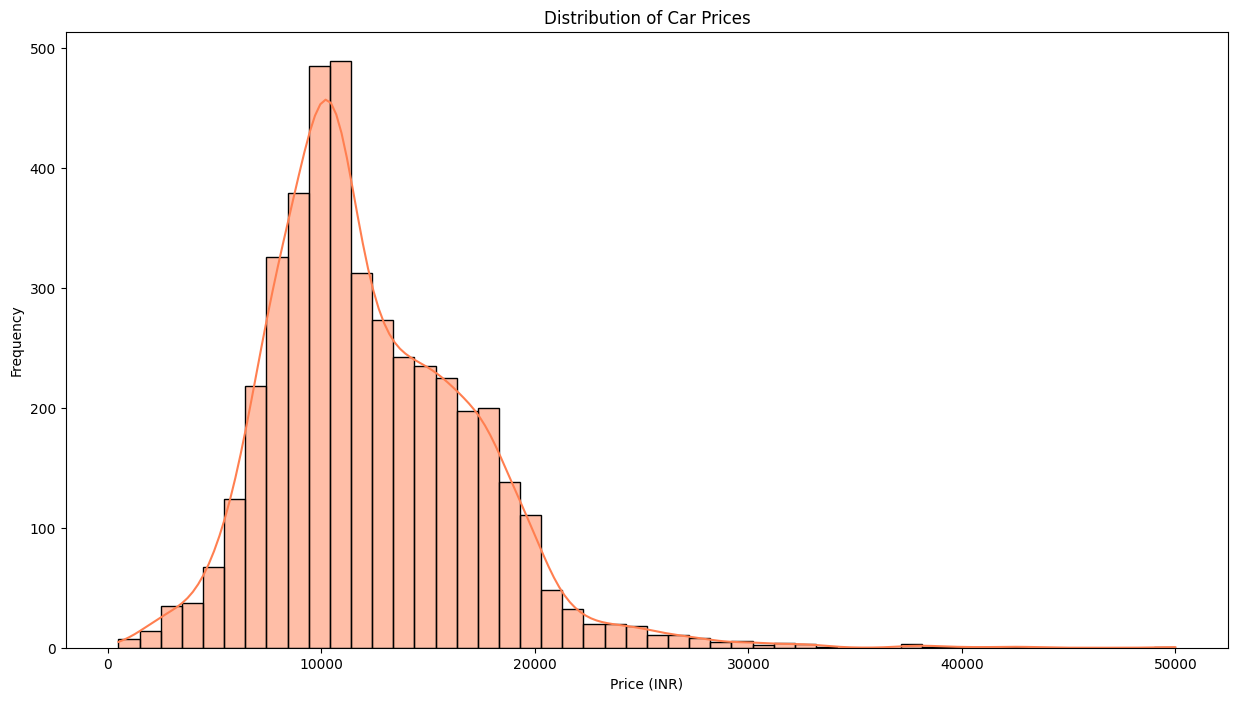

In [12]:
plt.figure(figsize=(15, 8))
sns.histplot(df_train['price'], bins=50, kde=True, color="coral")
plt.title('Distribution of Car Prices')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.show()

The target variable's distribution is essential. A highly skewed distribution can violate assumptions of some linear models and often benefits from transformation (e.g., logarithmic) before modeling.

Interpretation: The distribution is heavily right-skewed. The vast majority of cars are clustered at lower price points ($\sim 5,000$ to $20,000$), with a long tail extending towards higher prices. This indicates that the model must be robust in handling this inherent heterogeneity and concentration of data at the lower end.

**Price vs. Year of Manufacture**

A box plot shows $\text{price}$ distributions grouped by the $\text{year}$.

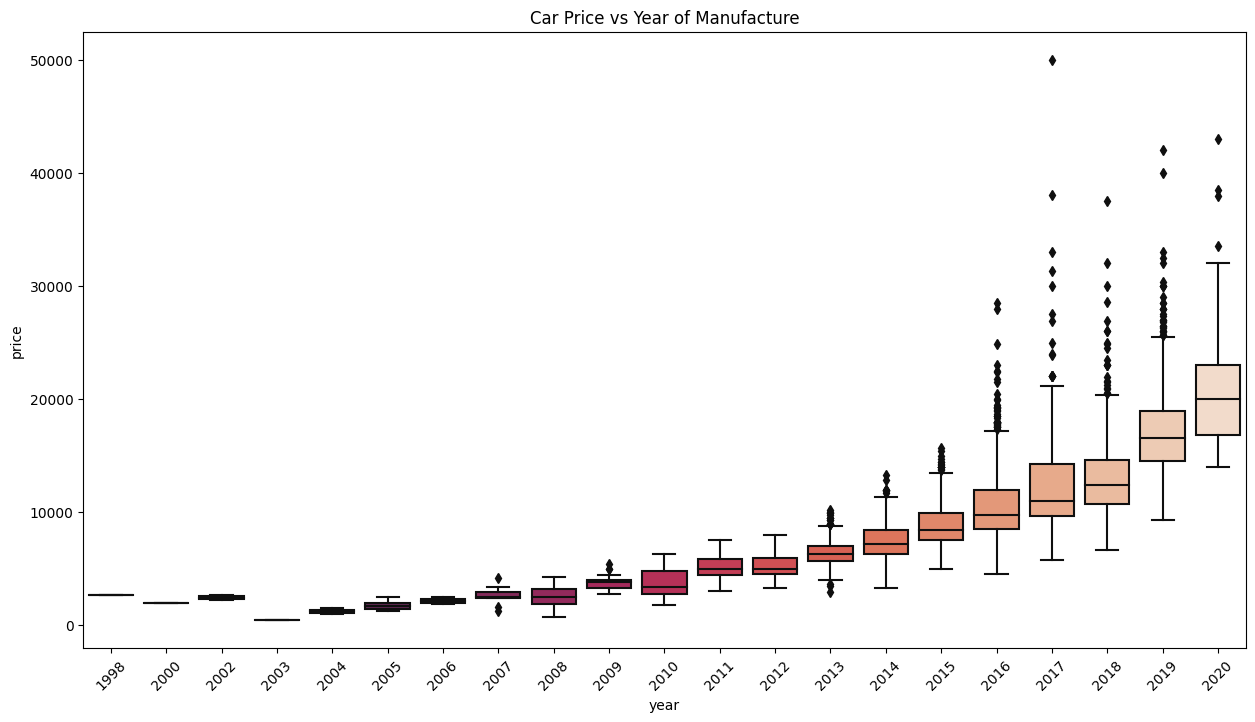

In [13]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='year', y='price', data=df_train, palette='rocket')
plt.xticks(rotation=45)
plt.title('Car Price vs Year of Manufacture')
plt.show()

Interpretation: A strong, positive linear trend is evident: as the year of manufacture increases (i.e., the car is newer), the median price significantly increases. This suggests $\text{year}$ will be a highly predictive feature for the $\text{SVR}$ model. Outliers, particularly for older cars, exist at higher prices, likely representing classic or niche models.

**Price vs. Model**

A box plot compares $\text{price}$ distributions across different car $\text{model}$ types.

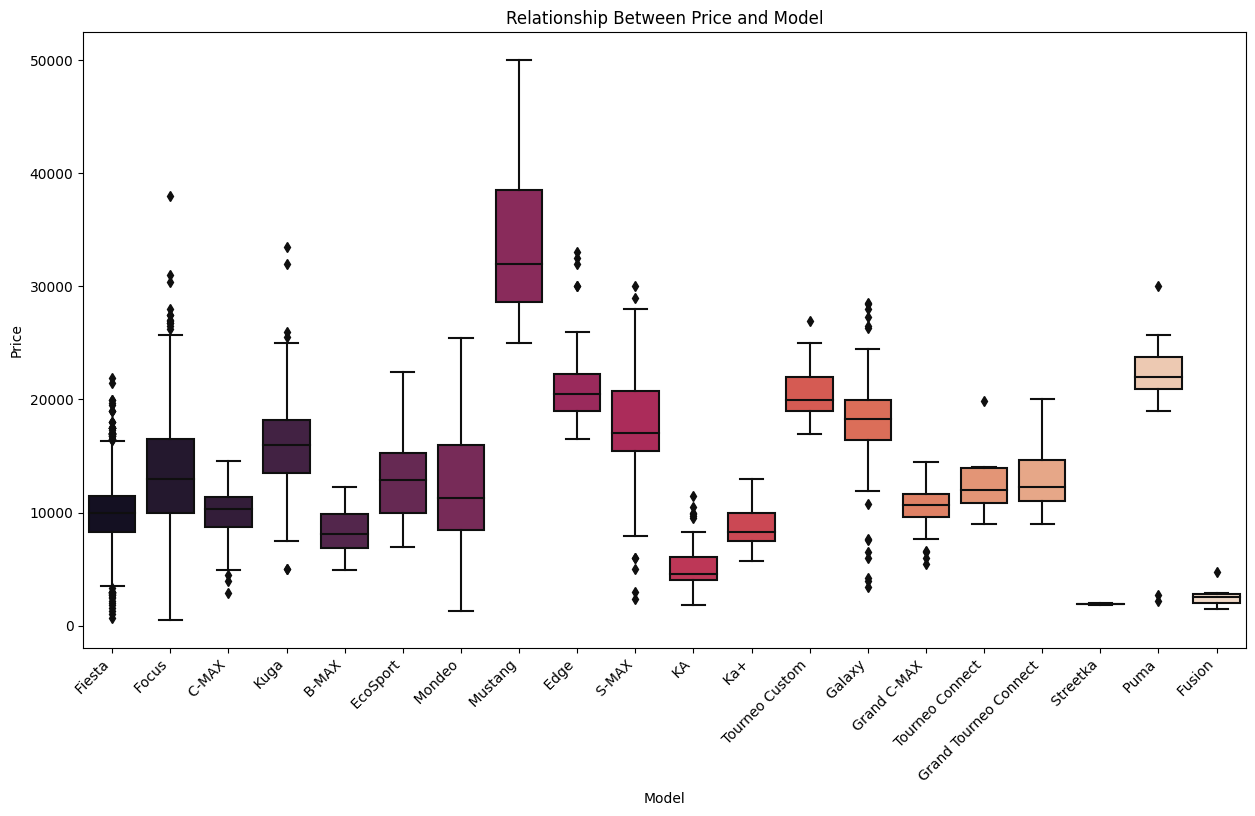

In [ ]:
plt.figure(figsize=(15, 8))

sns.boxplot(x="model", y="price", data=df_train, palette='rocket')

plt.xticks(rotation=45, ha="right")

plt.title("Relationship Between Price and Model")
plt.xlabel("Model")
plt.ylabel("Price")

plt.show()

Interpretation: Significant differences in median price exist between models. Models like $\text{Fiesta}$ and $\text{Focus}$ are generally entry-level and concentrated at lower prices, while models like $\text{Mustang}$ and $\text{Mondeo}$ have much higher median prices and wider ranges. This categorical feature is critical for price prediction.

**Price vs. Model and Transmission**

A strip plot layers $\text{transmission}$ type on top of the $\text{price}$ vs. $\text{model}$ relationship.

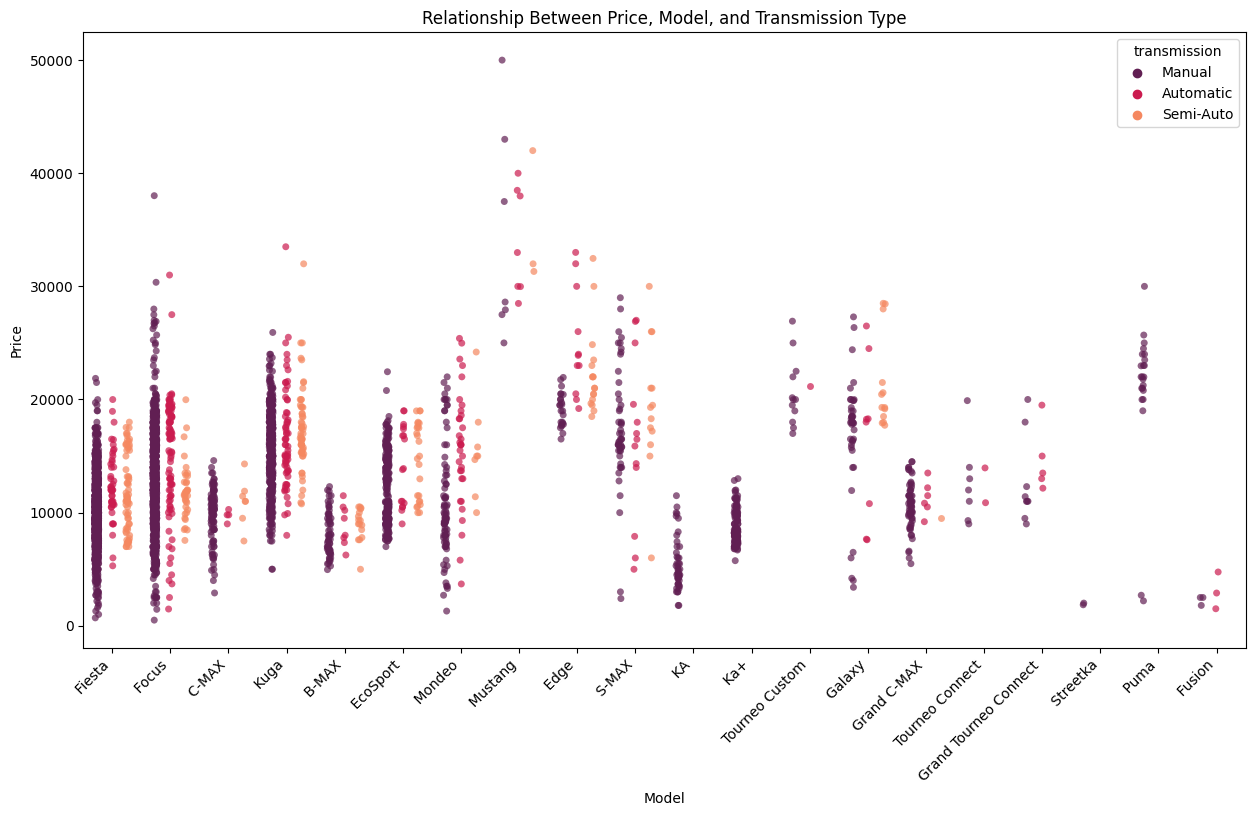

In [ ]:
plt.figure(figsize=(15, 8))

sns.stripplot(x="model", y="price", hue="transmission", data=df_train, jitter=True, dodge=True, alpha=0.7, palette='rocket')

plt.xticks(rotation=45, ha="right")

plt.title("Relationship Between Price, Model, and Transmission Type")
plt.xlabel("Model")
plt.ylabel("Price")

plt.show()

Interpretation: $\text{Transmission}$ type clearly differentiates price within models. Automatic transmissions often command a higher price point than manual transmissions within the same model group, particularly noticeable in higher-end models. This interaction suggests that the $\text{transmission}$ feature will also be important.

**Distribution of Transmission Types**

A pie chart illustrates the count percentage of different $\text{transmission}$ types.

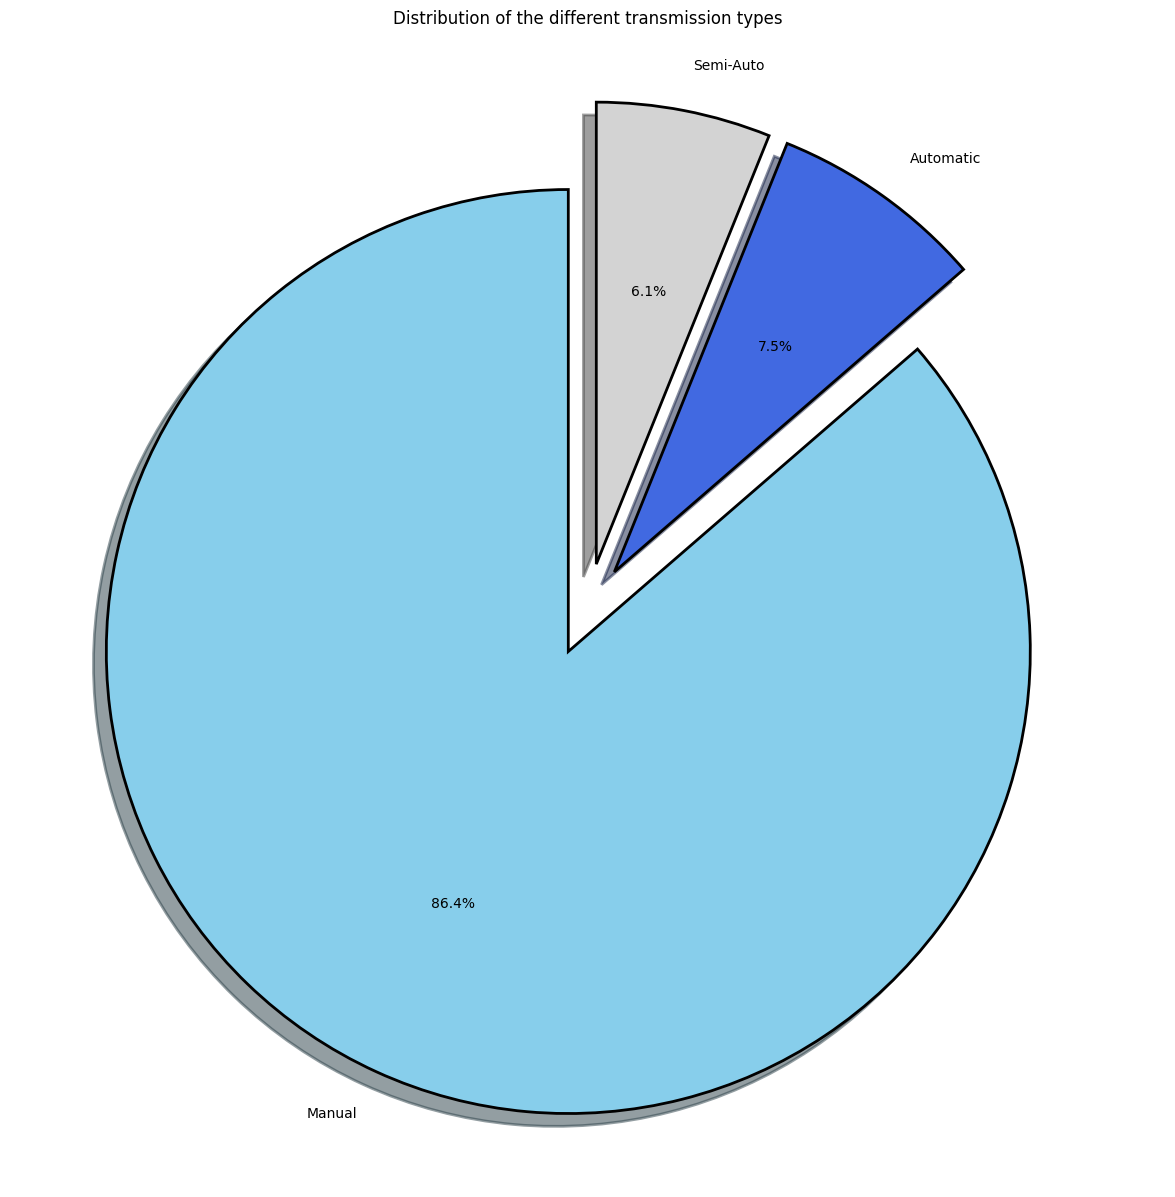

In [ ]:
fig = plt.figure(figsize=(15,15))
colors = ("skyblue", "royalblue", "lightgray")
wp = {'linewidth':2, 'edgecolor':"black"}
tags = df_train['transmission'].value_counts()

explode= (0.1, 0.1, 0.1)

tags.plot(kind='pie', autopct='%1.1f%%', shadow=True, colors = colors, startangle=90, 
          wedgeprops = wp, explode=explode, label='')
plt.title('Distribution of the different transmission types')
plt.show()

Interpretation: The vast majority of vehicles in the dataset have a $\text{Manual}$ transmission, followed by $\text{Automatic}$. The $\text{Semi-Automatic}$ category is the smallest. This class imbalance means the model will have significantly less data to learn the price characteristics of $\text{Semi-Automatic}$ vehicles.

**Price vs. Engine Size**

A scatter plot shows the relationship between $\text{engineSize}$ and $\text{price}$.

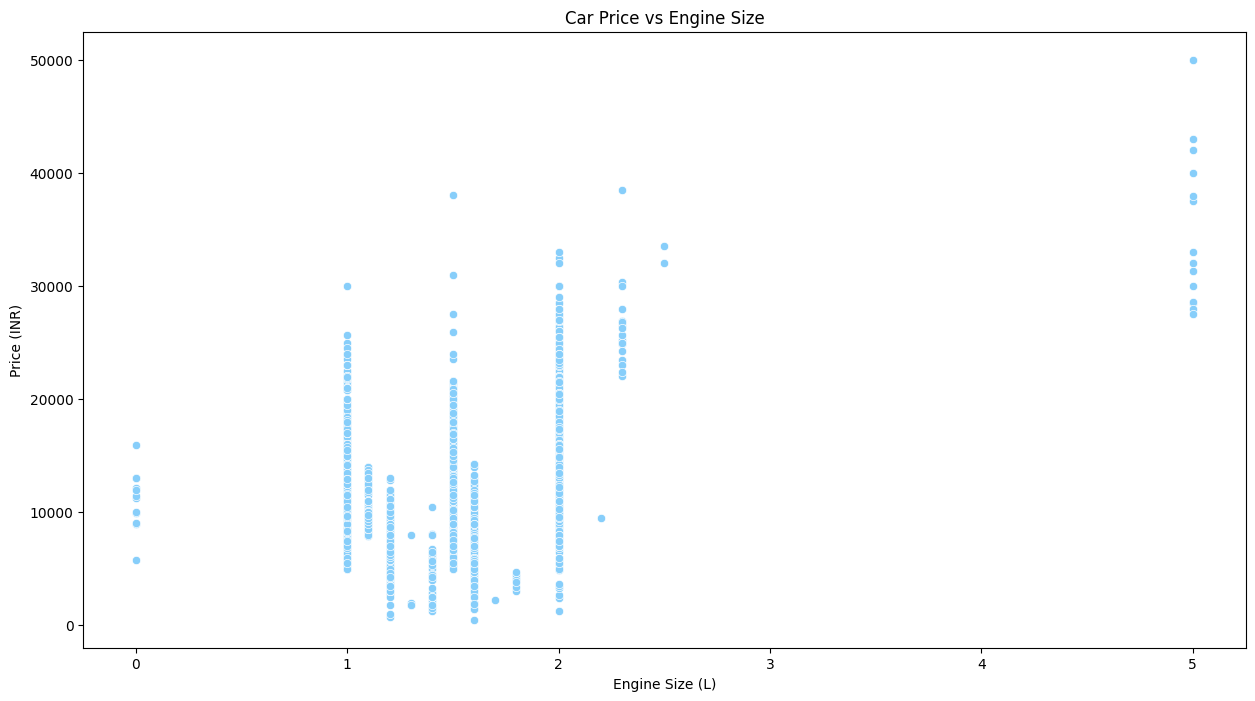

In [17]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x='engineSize', y='price', data=df_train, color='lightskyblue')
plt.title('Car Price vs Engine Size')
plt.xlabel('Engine Size (L)')
plt.ylabel('Price (INR)')
plt.show()

Interpretation: A clear non-linear, positive correlation exists: larger engine sizes generally correspond to higher car prices. However, the relationship is not simple; a wide range of prices exists for common engine sizes like $1.0\text{L}$ and $1.5\text{L}$. This pattern is well-suited for $\text{SVR}$ with a non-linear kernel like $\text{RBF}$ or polynomial, which can capture the curvature of this relationship.

**Price vs. Mileage**

A scatter plot shows $\text{mileage}$ against $\text{price}$.

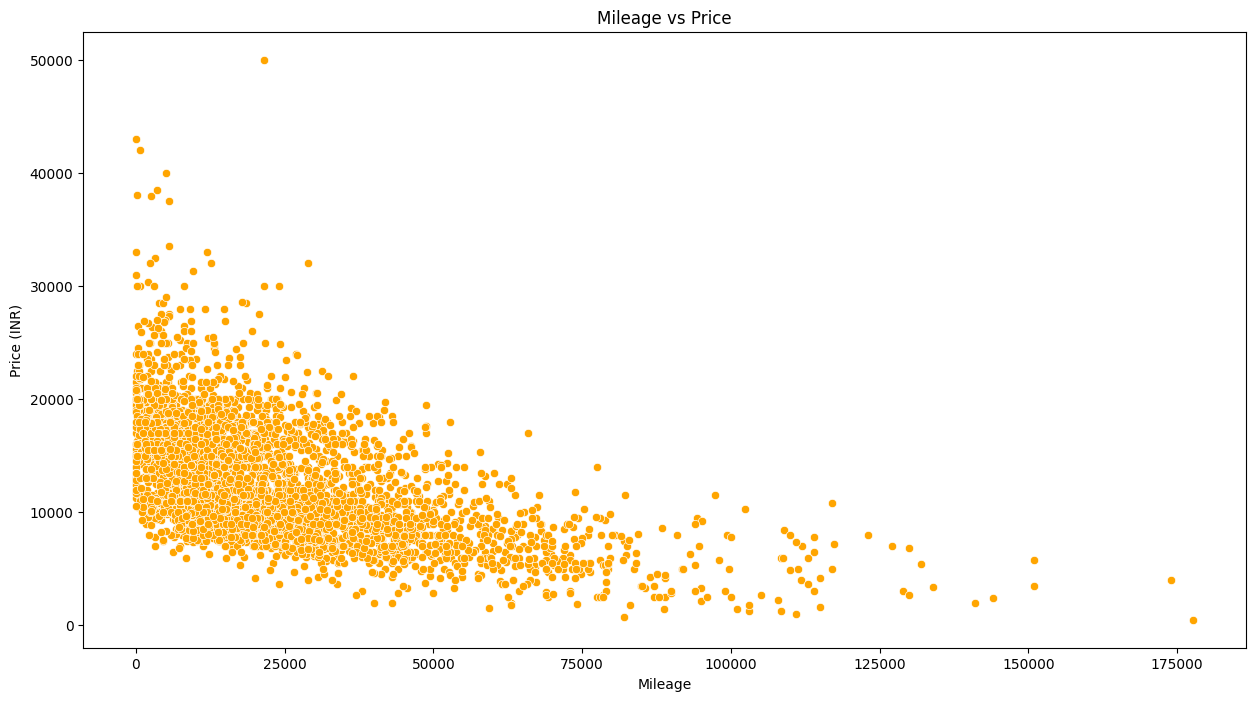

In [18]:
plt.figure(figsize=(15, 8))
sns.scatterplot(x='mileage', y='price', data=df_train, color='orange')
plt.title('Mileage vs Price')
plt.xlabel('Mileage')
plt.ylabel('Price (INR)')
plt.show()

Interpretation: A strong negative, non-linear relationship is observed: as $\text{mileage}$ increases, the price tends to decrease sharply. The highest prices are clustered at low mileage values, and the price drops off quickly as mileage accumulates. This aligns with the expected depreciation of a vehicle.

**Price vs. Fuel Type**

A box plot compares $\text{price}$ distributions across $\text{fuelType}$.

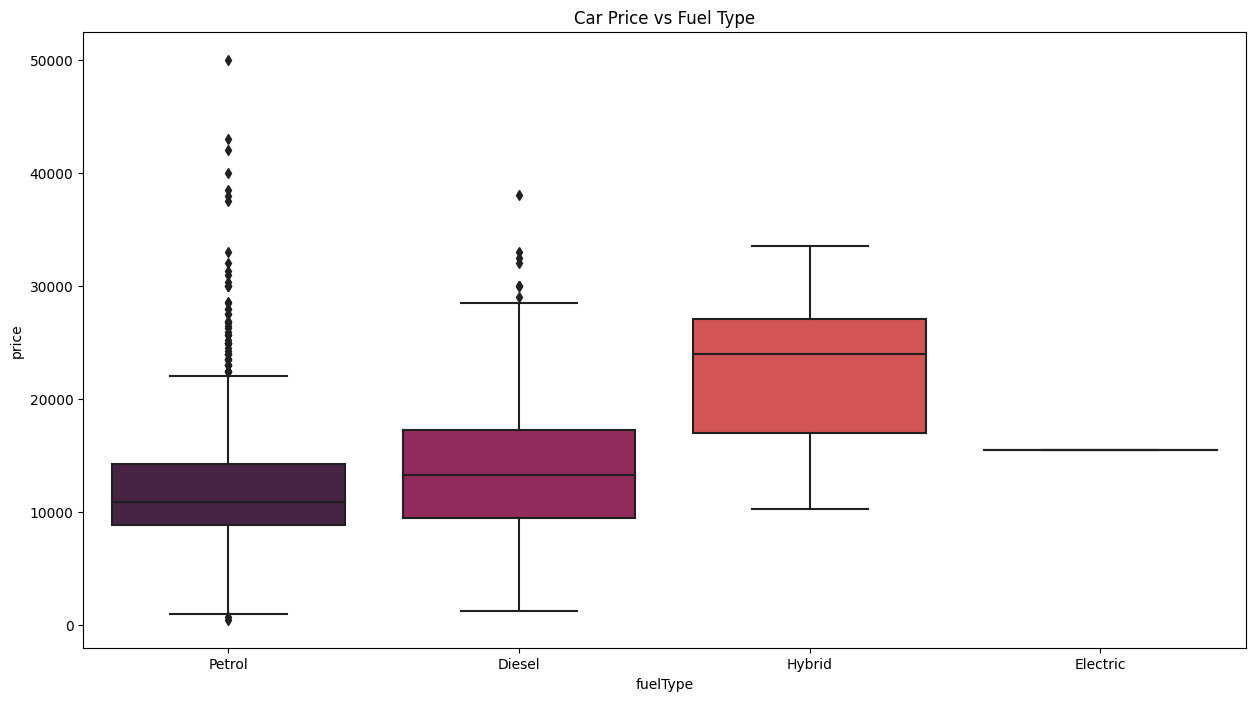

In [19]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='fuelType', y='price', data=df_train, palette='rocket')
plt.title('Car Price vs Fuel Type')
plt.show()

Interpretation: $\text{Diesel}$ and $\text{Petrol}$ types show similar median prices and spread, while the small number of $\text{Hybrid}$ and $\text{Electric}$ vehicles appear to have higher median price points. $\text{Electric}$ vehicles, despite having a small sample size, show a very high median price, making $\text{fuelType}$ a high-impact categorical predictor.

**Correlation Analysis**

Categorical variables are first converted to numerical form using $\text{LabelEncoder}$. A correlation heatmap is then generated from the encoded DataFrame.

Correlation measures the linear relationship between variables. High correlation between features (multicollinearity) can destabilize models like linear regression. However, $\text{SVR}$ is generally less affected by multicollinearity due to its regularization mechanism ($\text{C}$ parameter). The correlation between features and the target ($\text{price}$) indicates predictive strength.

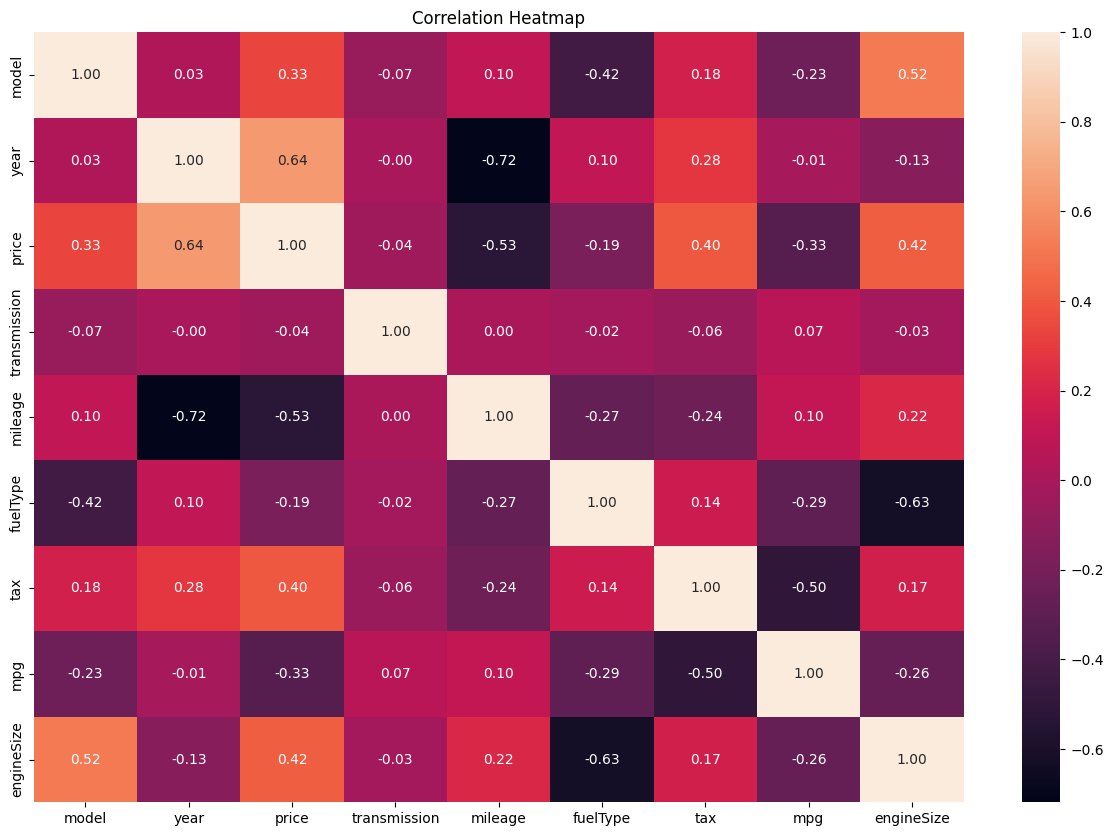

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['model', 'transmission', 'fuelType']

df_encoded = df_train.copy()
encoder = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

plt.figure(figsize=(15, 10))
sns.heatmap(df_encoded.corr(), annot=True, cmap='rocket', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Interpretation of Results**

The heatmap reveals several strong relationships with the target variable, $\text{price}$:
- Strong Positive Correlation: $\text{year}$ (expected, newer cars are more expensive), $\text{engineSize}$ (expected, larger engines are often in higher-tier models).
- Strong Negative Correlation: $\text{mileage}$ (expected, higher mileage leads to depreciation).
- Moderate Correlation: $\text{tax}$ and $\text{mpg}$ also show some linear association with price.

The correlations confirm that the selected features hold significant predictive power. The non-linear relationships observed in the scatter plots ($\text{engineSize}$ vs $\text{price}$, $\text{mileage}$ vs $\text{price}$) reinforce the necessity of using the Kernel Trick in $\text{SVR}$ to capture these complexities effectively.

# Features Engineering

**Duplicate Row Removing**

Duplicate rows are systematically identified and removed from both the training (`df_train`) and testing (`df_test`) datasets using the `drop_duplicates()` function.

Removing duplicates is a crucial step in data cleaning. Duplicate entries, especially in the training set, can lead to overfitting because the model sees the exact same observation multiple times, incorrectly inflating the perceived importance of those points. In the context of the $\epsilon$-insensitive tube of $\text{SVR}$, duplicate Support Vectors could unnecessarily bias the final hyperplane. The removal confirms the uniqueness of all remaining observations in both sets.

In [ ]:
df_train = df_train.drop_duplicates()

A = df_train.duplicated()
A = pd.DataFrame(A, columns=['Duplicated'])

unique_values = A['Duplicated'].unique()
unique_values

array([False])

In [ ]:
df_test = df_test.drop_duplicates()

A = df_train.duplicated()
A = pd.DataFrame(A, columns=['Duplicated'])

unique_values = A['Duplicated'].unique()
unique_values

array([False])

**Feature and Target Separation**

The $\text{price}$ column, which is the variable to be predicted, is isolated as the target vector (`y_train` and `y_test`). All other columns are retained as the feature matrices (`x_train` and `x_test`).

Machine learning models operate on the principle of learning a function $f$ such that $\hat{y} = f(\mathbf{x})$, where $\mathbf{x}$ are the independent features and $\hat{y}$ is the predicted dependent target. This explicit separation is a necessary structural step before applying any modeling algorithm.

In [ ]:
y_train = df_train['price'] 
x_train = df_train.drop('price', axis=1) 
y_test = df_test['price'] 
x_test = df_test.drop('price', axis=1) 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4299, 8)
y_train shape: (4299,)
X_test shape: (1078, 8)
y_test shape: (1078,)


**Data Normalization and Categorical Encoding**

Numerical columns ($\text{year}$, $\text{mileage}$, $\text{tax}$, $\text{mpg}$, $\text{engineSize}$) are standardized using $\text{StandardScaler}$. Categorical columns ($\text{model}$, $\text{transmission}$, $\text{fuelType}$) are converted to numerical format using $\text{OrdinalEncoder}$. Both transformations are fitted only on the training data and then applied to both sets.

Standardization (or Z-score normalization) transforms numerical data such that it has a mean of $0$ and a standard deviation of $1$. This is critical for distance-based algorithms like $\text{SVR}$ because it prevents features with larger numerical ranges ($\text{mileage}$) from dominating the distance calculations and the objective function's optimization process. Ordinal Encoding assigns an integer value to each unique category. While One-Hot Encoding is often preferred for nominal data, $\text{OrdinalEncoder}$ is used here to maintain a compact feature set, which is necessary before dimensionality reduction.

In [ ]:
if not isinstance(x_train, pd.DataFrame):
    x_train = pd.DataFrame(x_train)
if not isinstance(x_test, pd.DataFrame):
    x_test = pd.DataFrame(x_test)

numerical_cols = x_train.select_dtypes(include=[np.number]).columns
categorical_cols = x_train.select_dtypes(exclude=[np.number]).columns

scaler = StandardScaler()
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

x_train_numerical = pd.DataFrame(scaler.fit_transform(x_train[numerical_cols]), columns=numerical_cols, index=x_train.index)
x_test_numerical = pd.DataFrame(scaler.transform(x_test[numerical_cols]), columns=numerical_cols, index=x_test.index)

x_train_categorical = pd.DataFrame(encoder.fit_transform(x_train[categorical_cols]), columns=categorical_cols, index=x_train.index)
x_test_categorical = pd.DataFrame(encoder.transform(x_test[categorical_cols]), columns=categorical_cols, index=x_test.index)

x_train_processed = pd.concat([x_train_numerical, x_train_categorical], axis=1)
x_test_processed = pd.concat([x_test_numerical, x_test_categorical], axis=1)

x_train_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4299 entries, 17772 to 13250
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          4299 non-null   float64
 1   mileage       4299 non-null   float64
 2   tax           4299 non-null   float64
 3   mpg           4299 non-null   float64
 4   engineSize    4299 non-null   float64
 5   model         4299 non-null   float64
 6   transmission  4299 non-null   float64
 7   fuelType      4299 non-null   float64
dtypes: float64(8)
memory usage: 302.3 KB


**Dimensionality Reduction (PCA)**
    
**Principal Component Analysis - $\text{PCA}$**

$\text{PCA}$ is applied to the fully processed training and testing feature sets to reduce the feature space from $8$ dimensions to $2$ dimensions (`n_components=2`).

$\text{PCA}$ is an unsupervised linear transformation technique used for dimensionality reduction. It identifies the directions (principal components) in the data that maximize variance. The goal is to project the high-dimensional data onto a lower-dimensional subspace while retaining as much of the original data's information (variance) as possible. Reducing the data to $2$ components allows for easy visualization of the separation patterns, which is the primary purpose of this step. It can also speed up training for complex models like $\text{SVR}$, although it sacrifices some information.

In [ ]:
pca = PCA(n_components=2)  
x_train = pca.fit_transform(x_train_processed) 
x_test = pca.transform(x_test_processed)   

**Dimensionality Reduction Visualization**

A scatter plot is generated using the $2$ $\text{PCA}$ components ($\text{PC1}$ on the x-axis, $\text{PC2}$ on the y-axis). The data points are colored according to the target variable, $\text{price}$, using a continuous color palette.

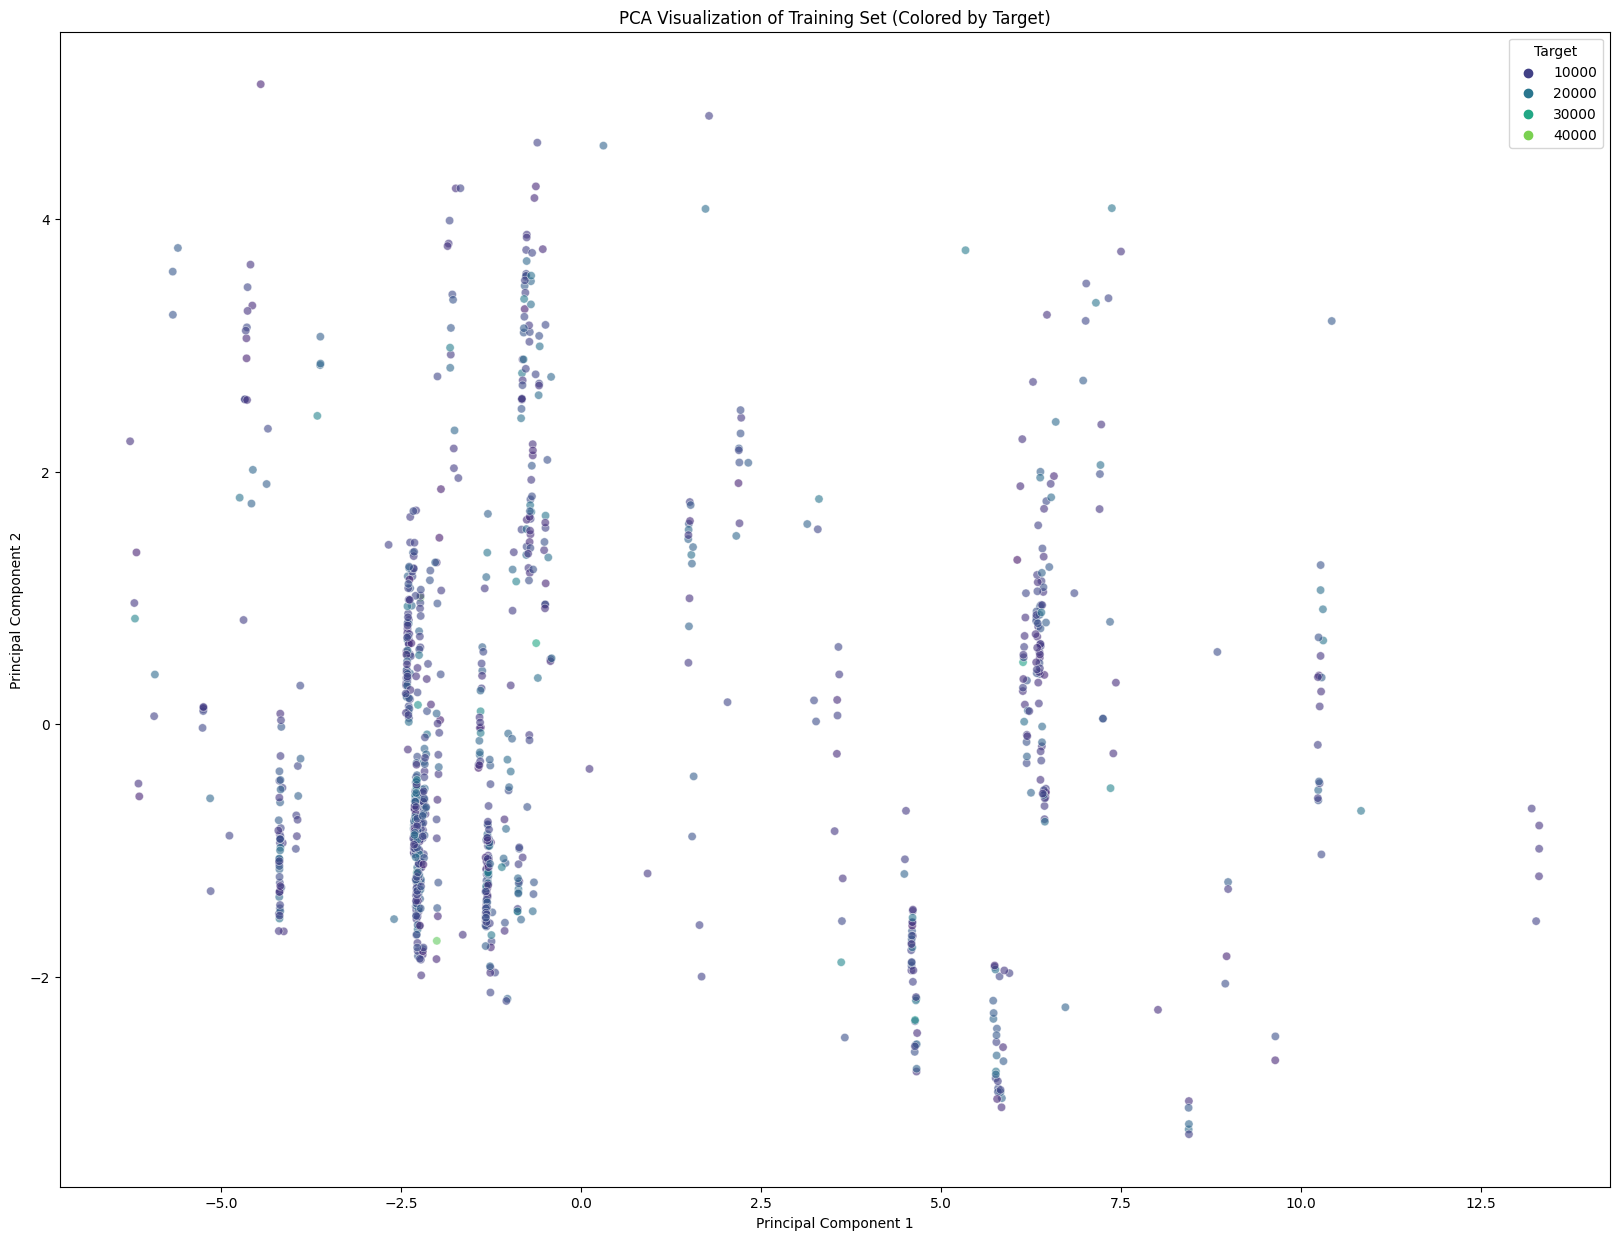

In [ ]:
x_train_pca_df = pd.DataFrame(x_train, columns=['PC1', 'PC2'])

plot_data = pd.DataFrame({
    'PC1': x_train_pca_df['PC1'],
    'PC2': x_train_pca_df['PC2'],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Training Set (Colored by Target)")

plt.show()

**Interpretation of Results**

The $\text{PCA}$ plot effectively visualizes the inherent structure of the price data in a $2\text{D}$ space. The plot shows a clear and well-separated gradient of color, primarily along the $\text{PC1}$ axis, moving from low prices (dark purple/blue) to high prices (yellow).
- PC1 as the Primary Price Driver: The horizontal axis ($\text{PC1}$) appears to capture the most significant variance related to the car's value. Data points far to the left (low $\text{PC1}$) correspond to low-priced cars, while points moving to the right (high $\text{PC1}$) correspond to high-priced cars. This confirms that the most important information dictating price (likely a composite of $\text{year}$ and $\text{engineSize}$) has been successfully retained and captured by the first principal component.
- Separability for SVR: The gradual separation suggests that while the data is complex, the underlying structure necessary for regression is preserved. The $\text{SVR}$ model, particularly if using a non-linear kernel, should be able to define a successful, non-linear boundary that follows this color gradient to predict car prices.

# Model Training, Experiments, and Model Visualization

**Initial Model Training and Validation**

Three variations of Support Vector Regression ($\text{SVR}$) models—$\text{LinearSVR}$, $\text{NuSVR}$, and standard $\text{SVR}$—are initialized and trained on the $2\text{D}$ $\text{PCA}$-reduced training data. K-fold cross-validation with $5$ folds is employed to evaluate model performance using three metrics: Negative Mean Squared Error ($\text{MSE}$), Negative Mean Absolute Error ($\text{MAE}$), and $\text{R-squared}$ ($\text{R}^2$).

Support Vector Machines (SVM), when adapted for regression, become $\text{SVR}$. The core principle is finding a hyperplane that best fits the data points while maximizing the margin (or $\epsilon$-tube) around the hyperplane. Data points falling within this tube do not contribute to the model error, which defines the $\epsilon$-insensitive loss function.
- $\text{LinearSVR}$ uses a linear kernel and is optimized using methods suitable for large linear problems.
- $\text{SVR}$ and $\text{NuSVR}$ offer non-linear capabilities through the Kernel Trick, allowing them to map data into higher dimensions to achieve a linear fit in that space.
- Cross-Validation ensures the model's performance is stable and not dependent on a particular training-test split, providing a reliable estimate of generalization ability.

In [ ]:
ml_models = [
    ("LinearSVR", LinearSVR(random_state=42, max_iter=1000)),  
    ("NuSVR", NuSVR()),
    ("SVR", SVR())
]


for name, model in ml_models:
    print(f"{name}: ")
    model.fit(x_train, y_train)  
    mse_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
    mae_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='r2')
    
    print("\tCross-Validation (Negative Mean Squared Error):", mse_scores)
    print(f'\tAverage Cross-Validation (Negative Mean Squared Error): {mse_scores.mean():.4f}')
    print("\tCross-Validation (Negative Mean Absolute Error):", mae_scores)
    print(f'\tAverage Cross-Validation (Negative Mean Absolute Error): {mae_scores.mean():.4f}')
    print("\tCross-Validation (R-squared):", r2_scores)
    print(f'\tAverage Cross-Validation (R-squared): {r2_scores.mean():.4f}')
    print('-' * 100)

LinearSVR: 
	Cross-Validation (Negative Mean Squared Error): [-9.84107876e+07 -1.04934489e+08 -1.15339583e+08 -1.02734950e+08
 -9.19186137e+07]
	Average Cross-Validation (Negative Mean Squared Error): -102667684.7039
	Cross-Validation (Negative Mean Absolute Error): [-8777.73106419 -9085.05074687 -9336.77829739 -8942.76013364
 -8614.03838016]
	Average Cross-Validation (Negative Mean Absolute Error): -8951.2717
	Cross-Validation (R-squared): [-3.24375407 -3.76708914 -3.23970128 -3.51765803 -3.73358618]
	Average Cross-Validation (R-squared): -3.5004
----------------------------------------------------------------------------------------------------
NuSVR: 
	Cross-Validation (Negative Mean Squared Error): [-22647571.2396439  -21534449.25429048 -26945716.85570623
 -22224187.78830576 -18974166.00804664]
	Average Cross-Validation (Negative Mean Squared Error): -22465218.2292
	Cross-Validation (Negative Mean Absolute Error): [-3697.8790657  -3613.71796766 -3851.80637984 -3629.90021694
 -3543.

**Interpretation of Results**

Negative $\text{MSE}$ and $\text{MAE}$: Since the $\text{scikit-learn}$ convention uses negative scoring for optimization, higher (less negative) values indicate better performance.
- $\text{LinearSVR}$ performs poorly, with an average negative $\text{MSE}$ around $-102,667,684.7$.
- $\text{NuSVR}$ and $\text{SVR}$ achieve significantly better results, with average negative $\text{MSE}$ scores around $-22,465,218.2$ and $-23,214,380.9$ respectively. The much lower magnitude of error indicates that the non-linear capabilities of these two models are essential for capturing the relationship in the data.

$\text{R-squared}$ ($\text{R}^2$): This metric represents the proportion of the variance in the dependent variable that is predictable from the independent variables. Values closer to $1.0$ are desired.
- $\text{LinearSVR}$ yields highly negative $\text{R}^2$ values (average $-3.5$), indicating that it performs worse than simply predicting the mean of the target variable.
- $\text{NuSVR}$ shows a slightly positive average $\text{R}^2$ of $0.0200$, suggesting a very marginal fit.
- $\text{SVR}$ shows a slightly negative average $\text{R}^2$ of $-0.0111$.

Overall, the initial results indicate that while the non-linear $\text{SVR}$ and $\text{NuSVR}$ models are better than $\text{LinearSVR}$, all models show weak predictive power on the $2\text{D}$ $\text{PCA}$ data, likely due to the loss of critical information during the dimensional reduction phase.

**Different SVM classifiers kernal function for regression using regression hypersurface**

Visualizing SVR Regression Hypersurfaces (2D and 3D)

Four different kernel functions ($\text{linear}$, $\text{LinearSVR}$ equivalent, $\text{RBF}$, and $\text{polynomial}$) are applied using both the $\text{SVR}$ and $\text{NuSVR}$ implementations. The models are fitted on the $2\text{D}$ $\text{PCA}$ data, and their predicted regression surfaces are visualized in both $2\text{D}$ contour plots and $3\text{D}$ surface plots.

The choice of the kernel function is crucial for $\text{SVR}$'s ability to model non-linear relationships.
- The Linear Kernel attempts to find a flat hyperplane, which is effective only if the relationship is mostly linear.
- The Radial Basis Function ($\text{RBF}$) Kernel is non-linear and operates by measuring the similarity between two points. It is highly flexible and often performs well when the data is not linearly separable. The $\gamma$ parameter controls the influence of a single training example; low $\gamma$ means a large influence (smoother boundary), while high $\gamma$ means a local influence (more complex boundary).
- The Polynomial Kernel generates higher-order feature combinations (controlled by the degree parameter), allowing for parabolic or more complex curved regression surfaces.

**SVR Regression Hypersurfaces 2D Visualization**

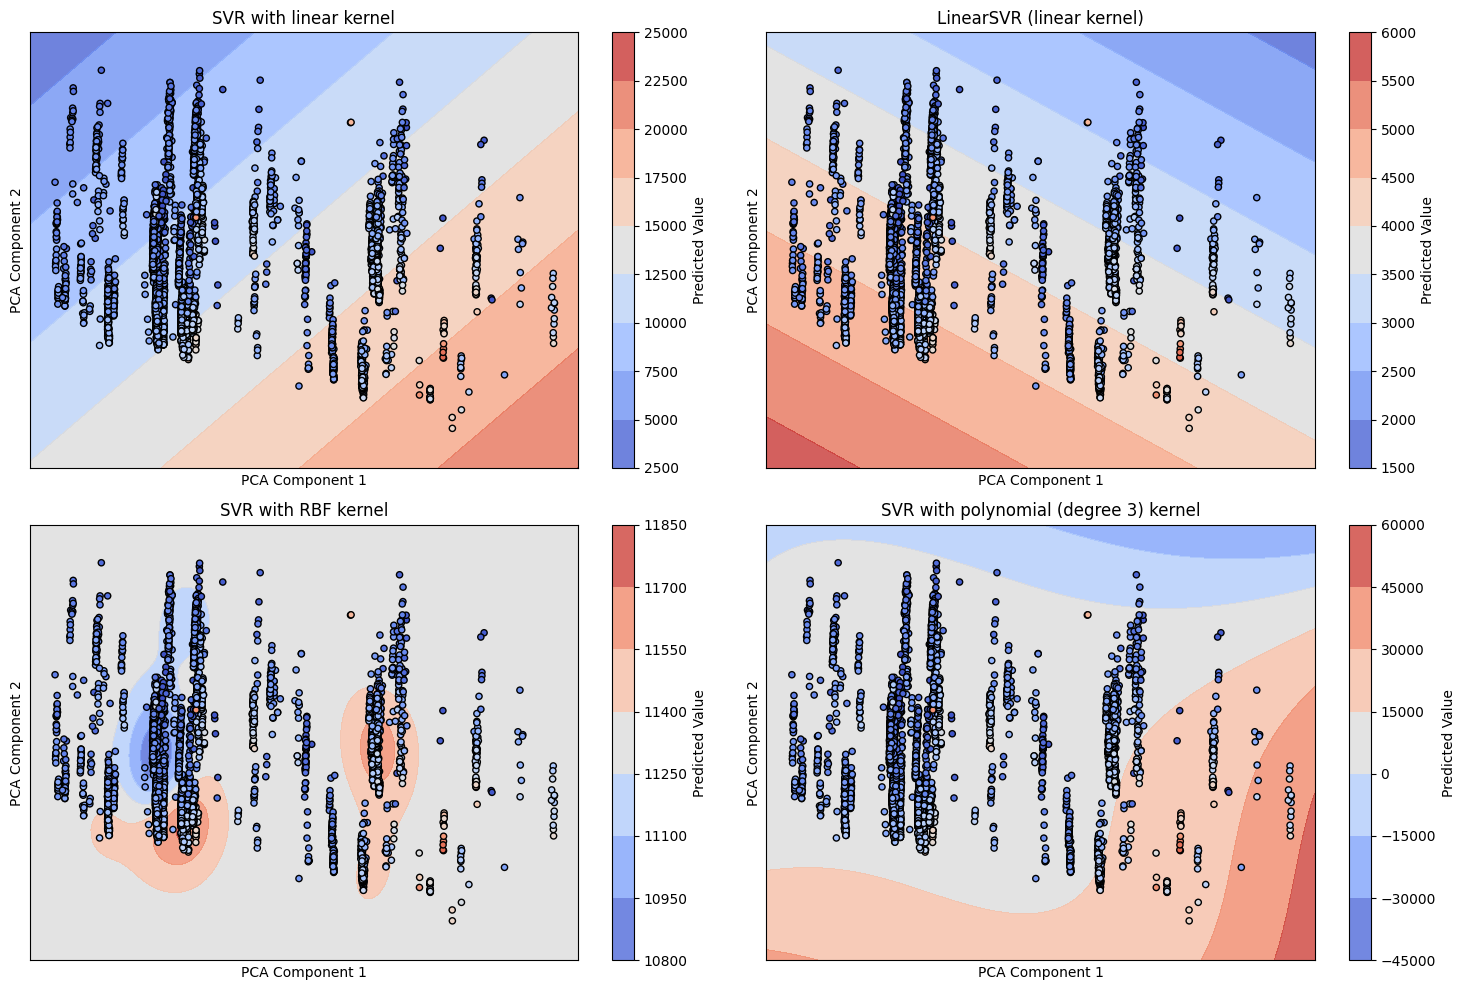

In [ ]:
C = 1.0
models = [
    SVR(kernel="linear", C=C),
    LinearSVR(C=C, max_iter=10000),
    SVR(kernel="rbf", gamma=0.7, C=C),
    SVR(kernel="poly", degree=3, gamma="auto", C=C),
]

try:
    fitted_models = [clf.fit(x_train, y_train) for clf in models]
except Exception as e:
    print(f"Error fitting models: {e}")
    raise

titles = (
    "SVR with linear kernel",
    "LinearSVR (linear kernel)",
    "SVR with RBF kernel",
    "SVR with polynomial (degree 3) kernel",
)

fig, sub = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

for clf, title, ax in zip(fitted_models, titles, sub.flatten()):
    try:
        x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
        y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        
        Z = clf.predict(grid_points)
        Z = Z.reshape(xx.shape)

        contour = ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
        fig.colorbar(contour, ax=ax, label='Predicted Value')
        
        X0, X1 = x_train[:, 0], x_train[:, 1]
        ax.scatter(X0, X1, c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
        
        ax.set_xticks(())
        ax.set_yticks(())
        ax.set_xlabel('PCA Component 1')
        ax.set_ylabel('PCA Component 2')
        ax.set_title(title)
    except Exception as e:
        print(f"Error plotting {title}: {e}")

plt.tight_layout()
plt.show()

**SVR Regression Hypersurfaces 3D Visualization**

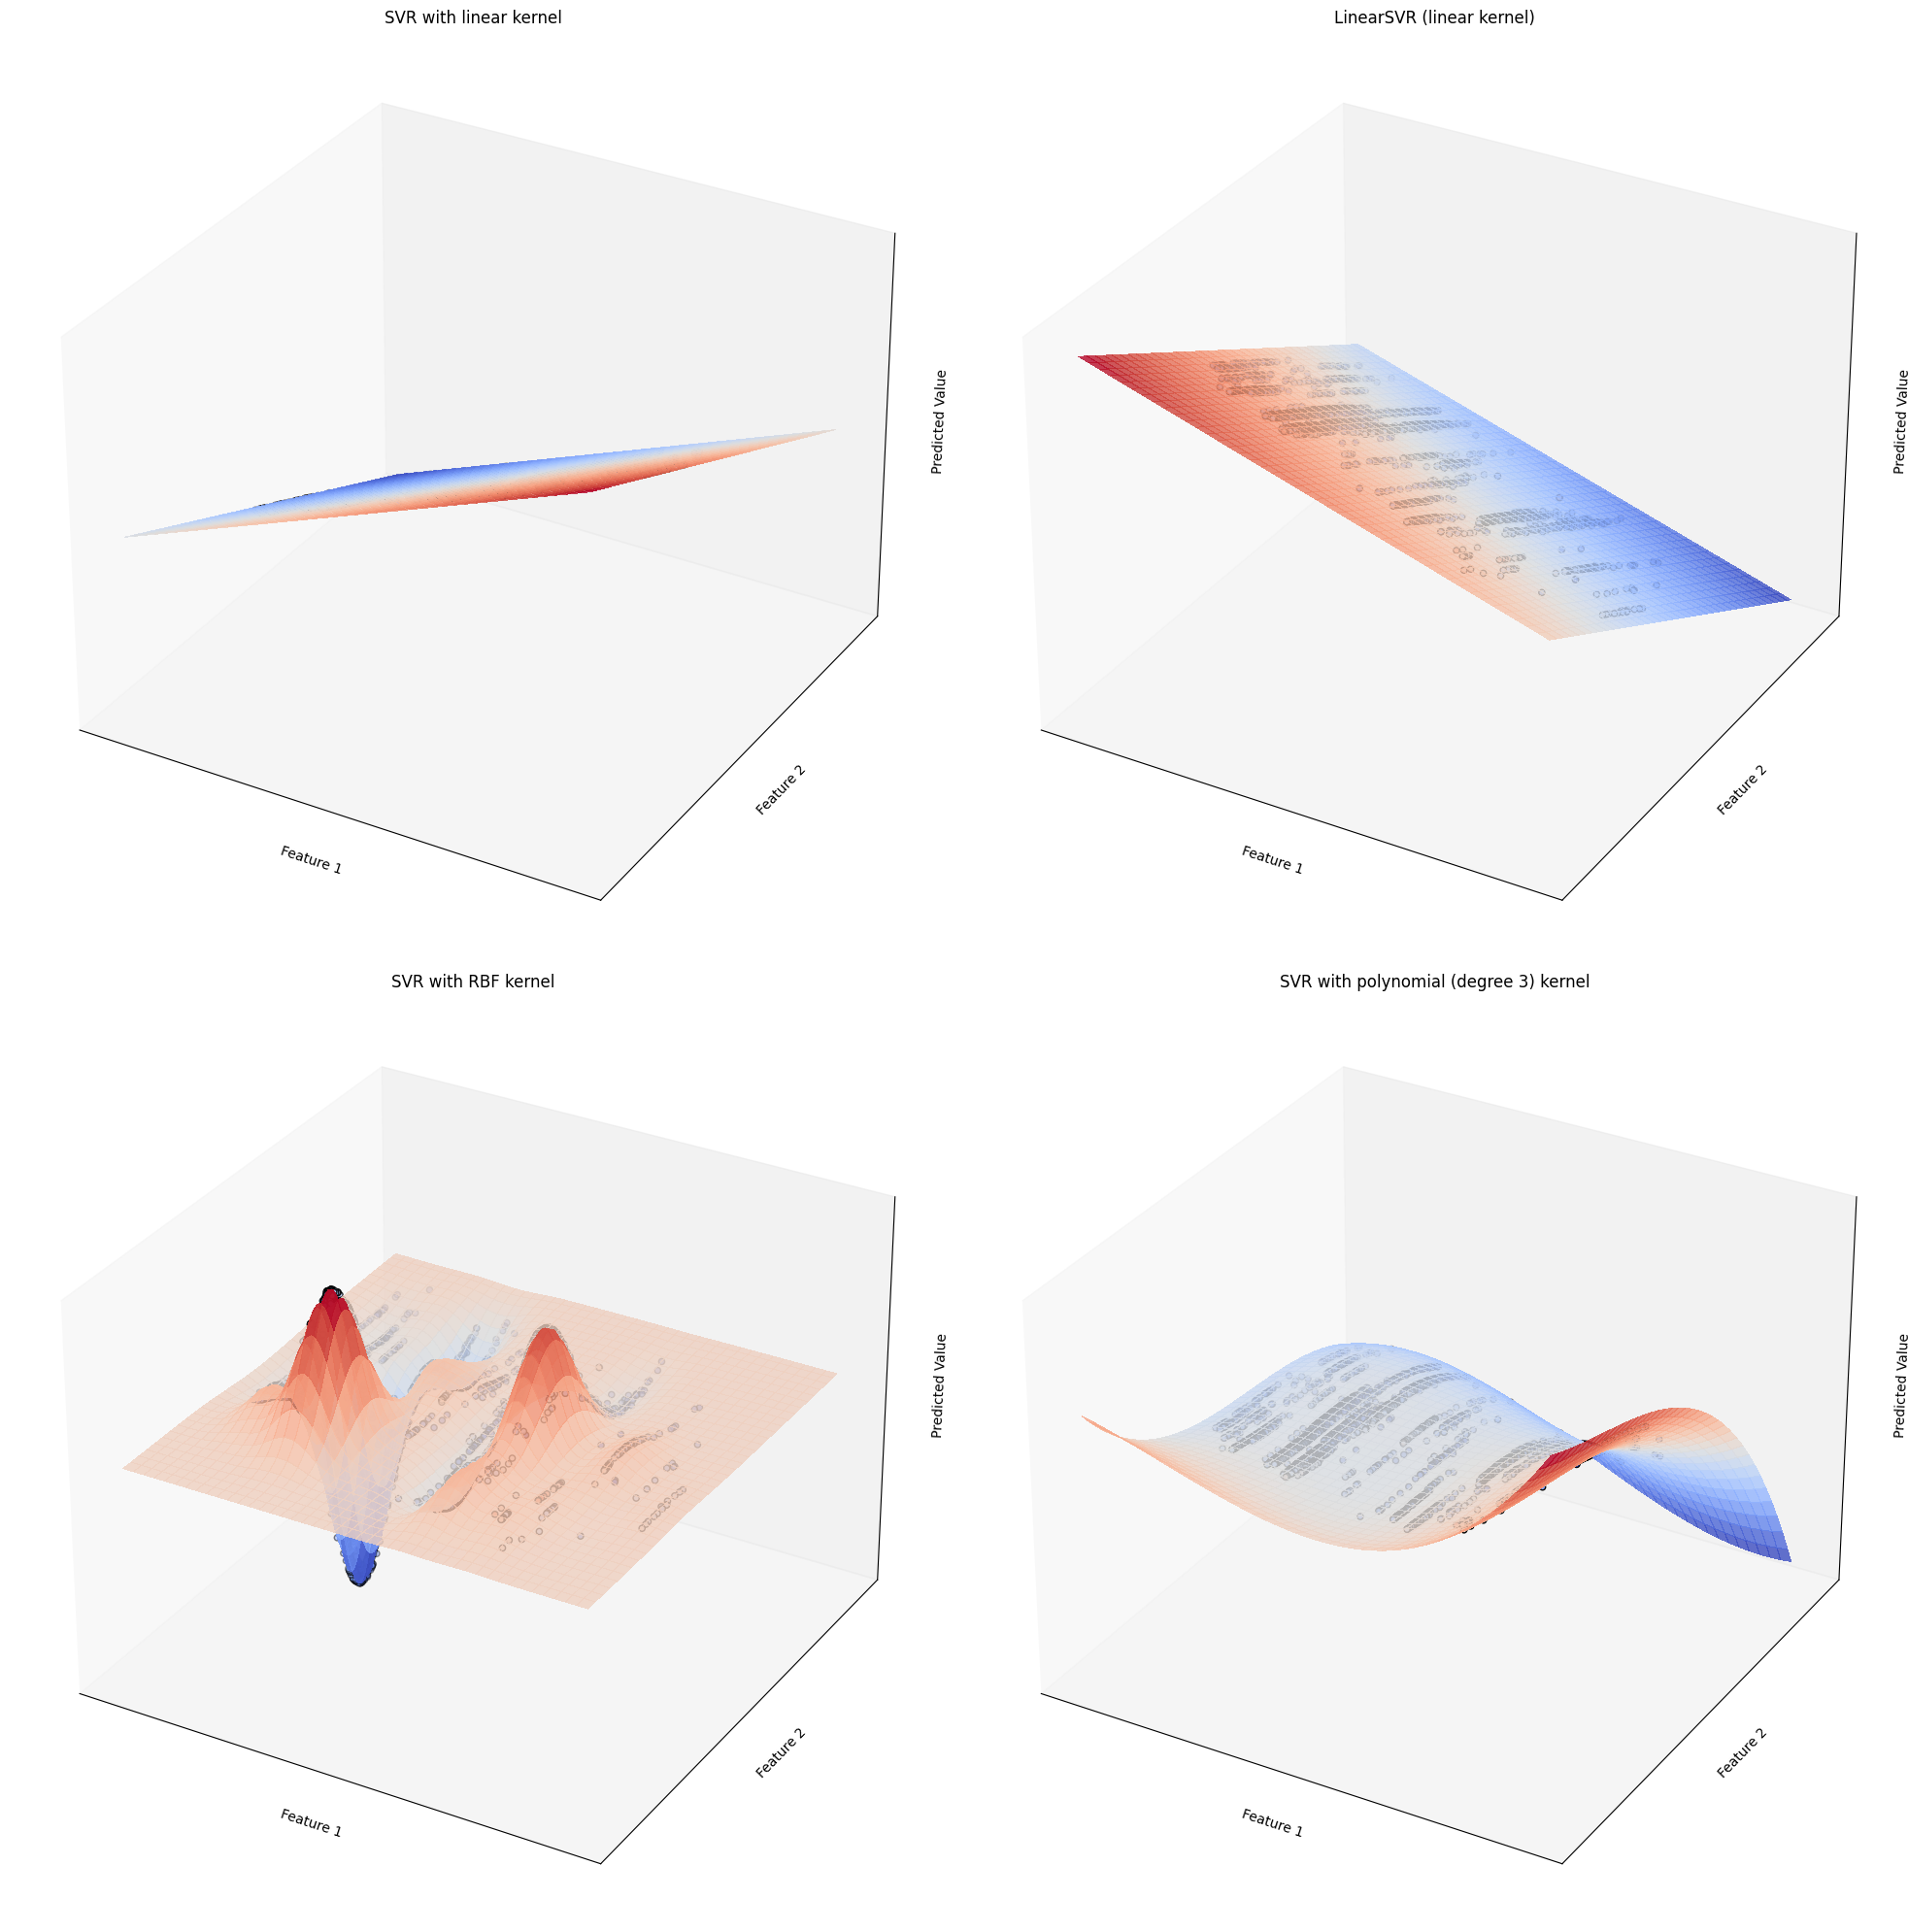

In [ ]:
C = 1.0
models = [
    SVR(kernel="linear", C=C),
    LinearSVR(C=C, max_iter=10000),
    SVR(kernel="rbf", gamma=0.7, C=C),
    SVR(kernel="poly", degree=3, gamma="auto", C=C),
]

try:
    fitted_models = [clf.fit(x_train, y_train) for clf in models]
except Exception as e:
    print(f"Error fitting models: {e}")
    raise

titles = (
    "SVR with linear kernel",
    "LinearSVR (linear kernel)",
    "SVR with RBF kernel",
    "SVR with polynomial (degree 3) kernel",
)

fig = plt.figure(figsize=(20, 20))
axes = [fig.add_subplot(2, 2, i+1, projection='3d') for i in range(4)]

for clf, title, ax in zip(fitted_models, titles, axes):
    try:
        x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
        y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        
        Z = clf.predict(grid_points)
        Z = Z.reshape(xx.shape)

        surf = ax.plot_surface(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8, linewidth=0, antialiased=False)

        X0, X1 = x_train[:, 0], x_train[:, 1]
        Z_train = clf.predict(x_train)
        scatter = ax.scatter(X0, X1, Z_train, c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')

        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.set_zlabel('Predicted Value')
        ax.set_title(title)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])

    except Exception as e:
        print(f"Error plotting {title}: {e}")

plt.tight_layout()
plt.show()

**Interpretation of Visualization Results**

SVR (Standard $\text{SVR}$)

- Linear Kernel Plots ($\text{SVR}$ and $\text{LinearSVR}$): Both $2\text{D}$ and $3\text{D}$ plots for the linear kernels show a predicted surface that is largely flat, or a simple inclined plane, across the entire feature space. The color gradient on the surface is smooth and predominantly follows the direction of $\text{PC1}$. This confirms that the model assumes a simple linear relationship between $\text{PC1}$ and $\text{PC2}$ and the car $\text{price}$. This flatness explains the poor $\text{R}^2$ scores, as the true data points exhibit clear non-linearity on the $\text{PC1}$ axis, as seen by the dense concentration of points versus the broad surface.
- $\text{RBF}$ Kernel Plots ($\text{SVR}$): The $2\text{D}$ contour plot and the $3\text{D}$ surface plot display significantly more complex, non-linear curvature. The surface is clearly warped to fit the cloud of data points. In $3\text{D}$, the surface exhibits pronounced peaks and valleys, particularly along the $\text{PC1}$ axis where the data is most spread out in terms of price. This indicates the $\text{RBF}$ kernel successfully used the $\text{Kernel Trick}$ to find a non-linear regression function in the $2\text{D}$ space, achieving a closer fit to the data distribution.
- Polynomial Kernel Plots ($\text{SVR}$): Similar to the $\text{RBF}$ kernel, the polynomial kernel generates a curved, non-linear regression surface, demonstrating flexibility. The specific shape of the curvature is different from $\text{RBF}$, being more constrained by the polynomial degree, but it also attempts to follow the price gradient along $\text{PC1}$ more accurately than the linear model.

**NuSVR Regression Hypersurfaces 2D Visualization**

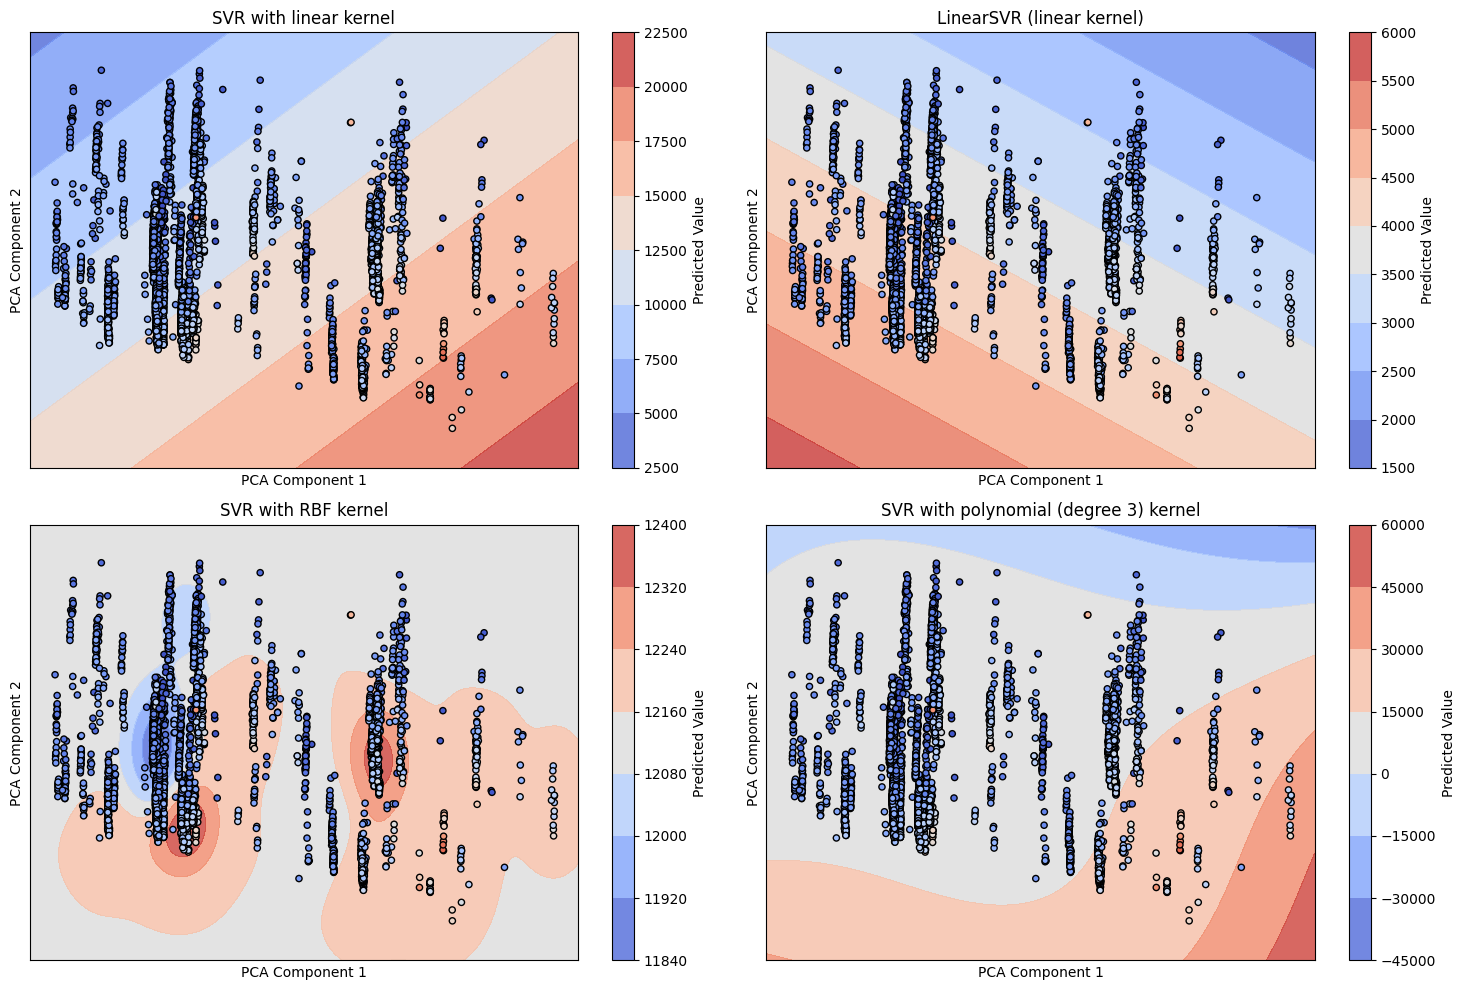

In [ ]:
C = 1.0
models = [
    NuSVR(kernel="linear", C=C),
    LinearSVR(C=C, max_iter=10000),
    NuSVR(kernel="rbf", gamma=0.7, C=C),
    NuSVR(kernel="poly", degree=3, gamma="auto", C=C),
]

try:
    fitted_models = [clf.fit(x_train, y_train) for clf in models]
except Exception as e:
    print(f"Error fitting models: {e}")
    raise

titles = (
    "SVR with linear kernel",
    "LinearSVR (linear kernel)",
    "SVR with RBF kernel",
    "SVR with polynomial (degree 3) kernel",
)

fig, sub = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

for clf, title, ax in zip(fitted_models, titles, sub.flatten()):
    try:
        x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
        y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        
        Z = clf.predict(grid_points)
        Z = Z.reshape(xx.shape)

        contour = ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
        fig.colorbar(contour, ax=ax, label='Predicted Value')
        
        X0, X1 = x_train[:, 0], x_train[:, 1]
        ax.scatter(X0, X1, c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
        
        ax.set_xticks(())
        ax.set_yticks(())
        ax.set_xlabel('PCA Component 1')
        ax.set_ylabel('PCA Component 2')
        ax.set_title(title)
    except Exception as e:
        print(f"Error plotting {title}: {e}")

plt.tight_layout()
plt.show()

**NuSVR Regression Hypersurfaces 3D Visualization**

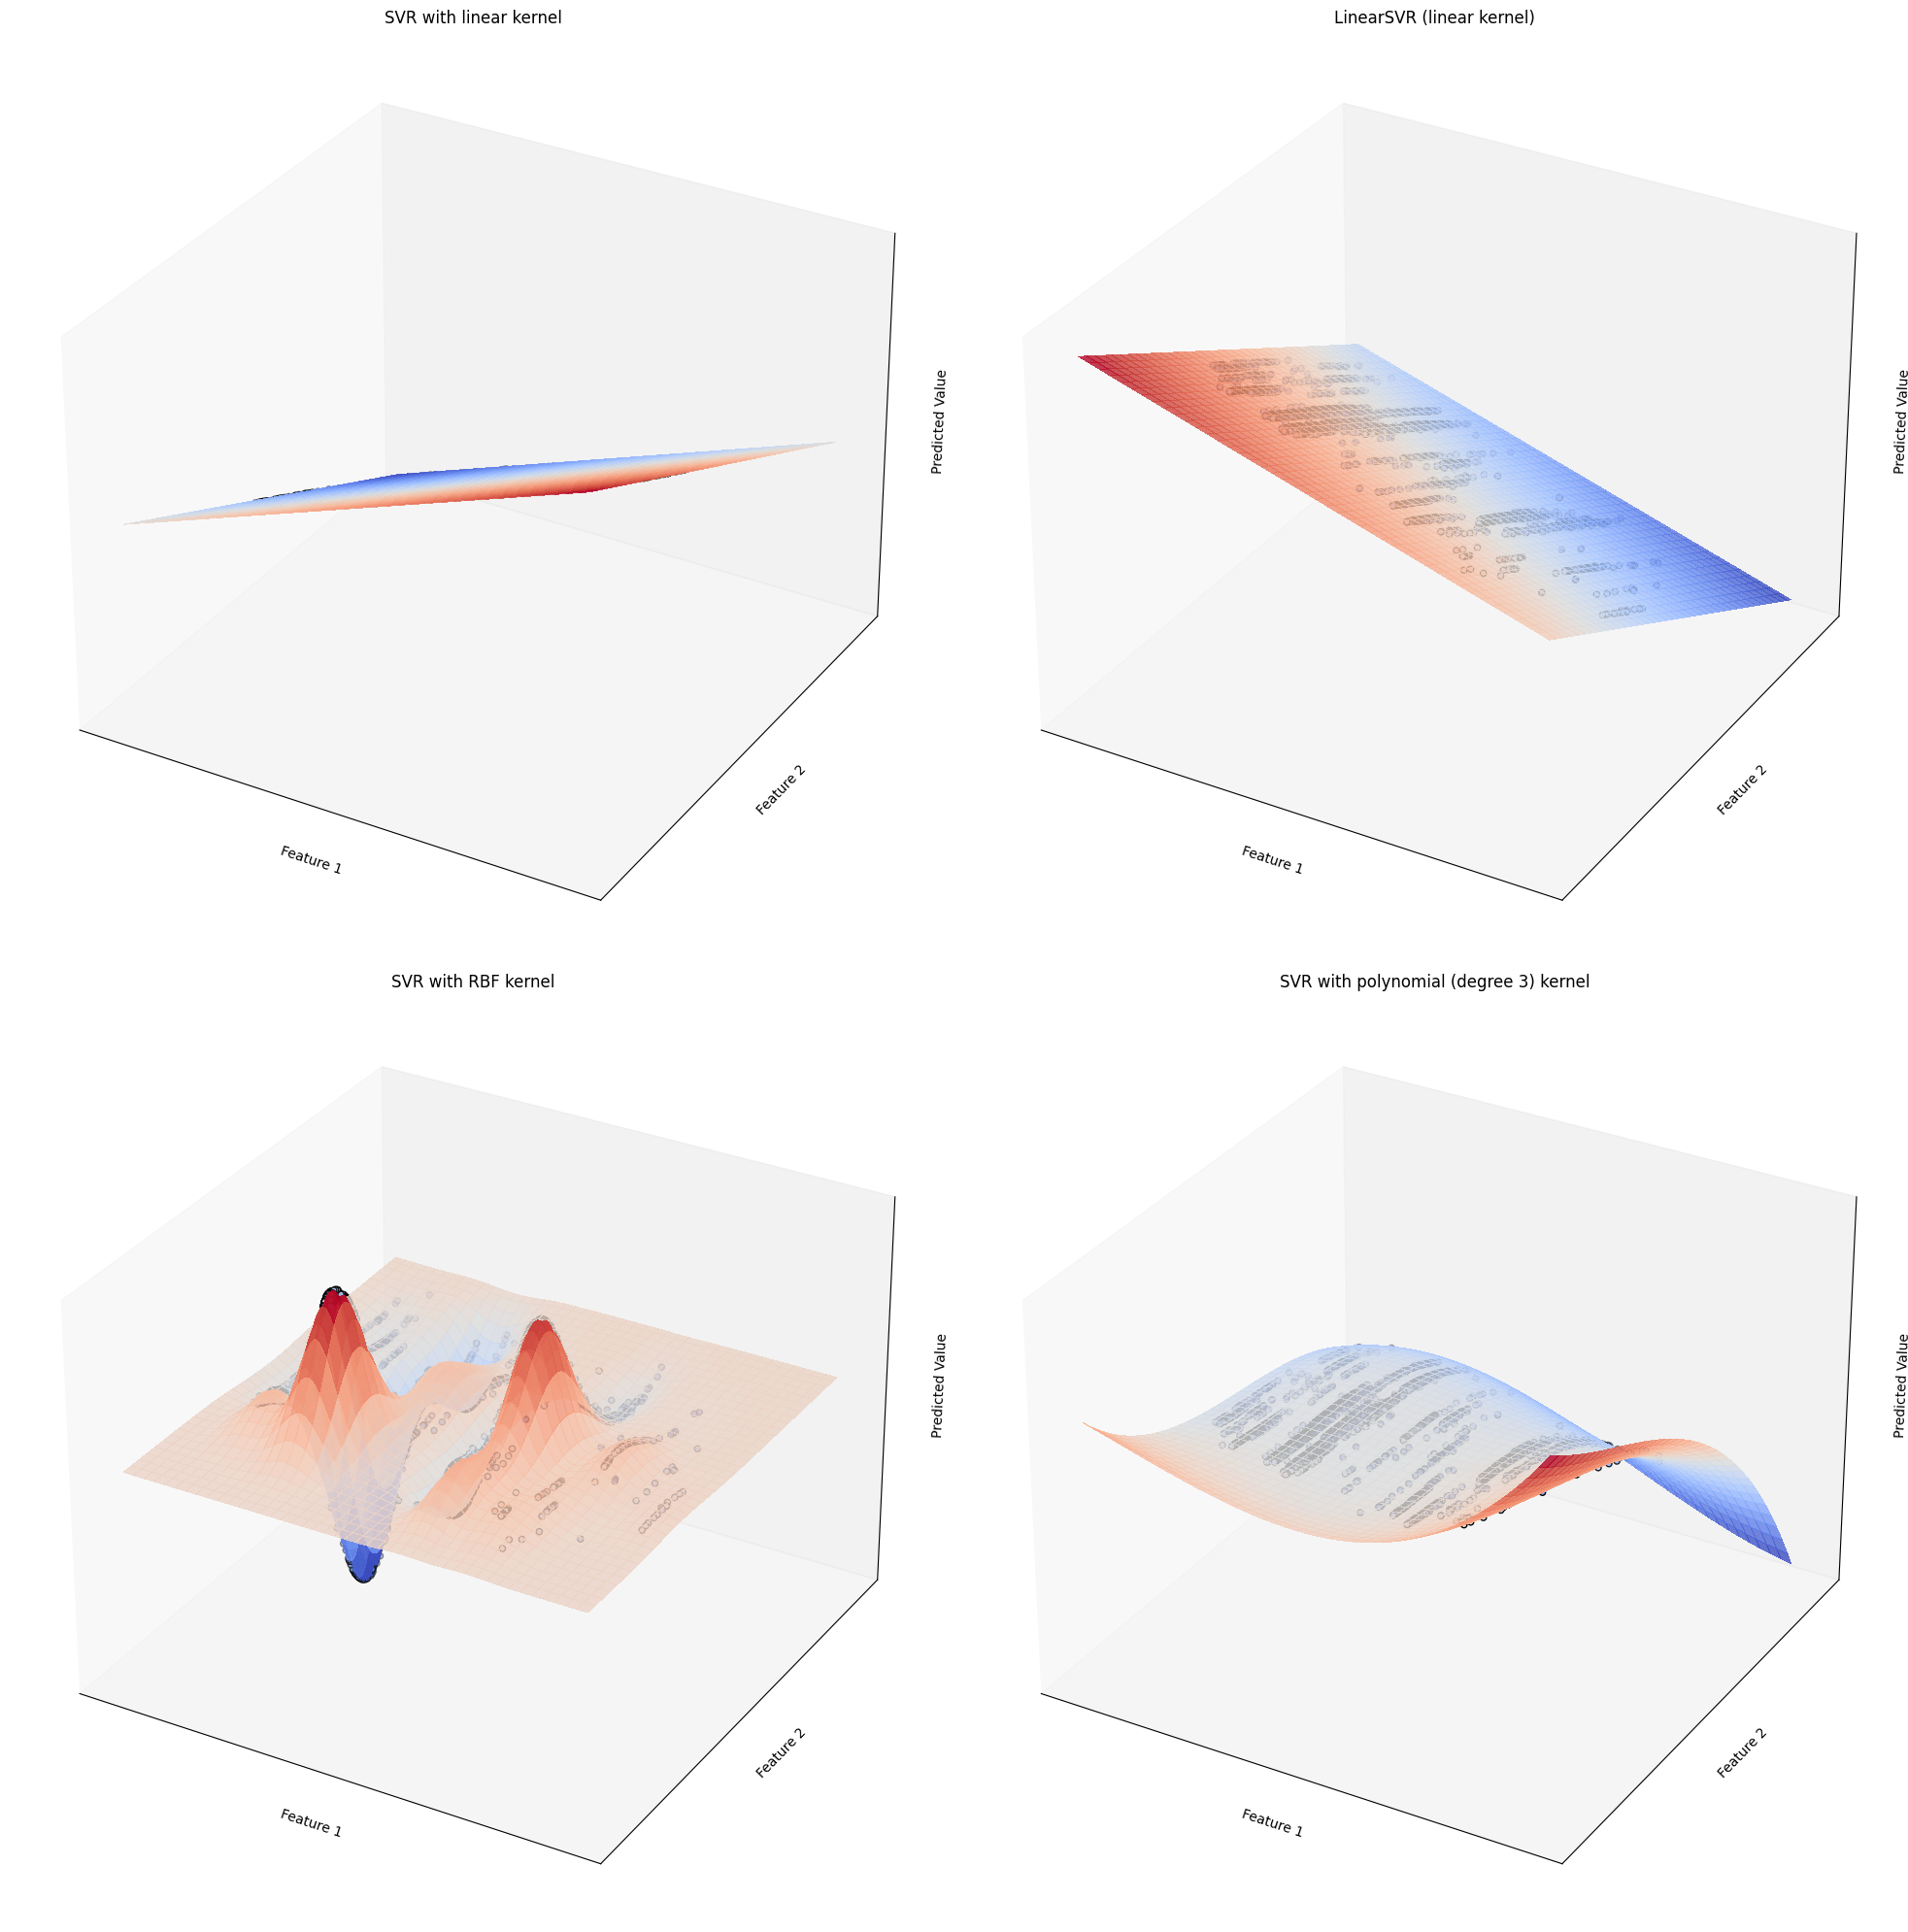

In [ ]:
C = 1.0
models = [
    NuSVR(kernel="linear", C=C),
    LinearSVR(C=C, max_iter=10000),
    NuSVR(kernel="rbf", gamma=0.7, C=C),
    NuSVR(kernel="poly", degree=3, gamma="auto", C=C),
]

try:
    fitted_models = [clf.fit(x_train, y_train) for clf in models]
except Exception as e:
    print(f"Error fitting models: {e}")
    raise

titles = (
    "SVR with linear kernel",
    "LinearSVR (linear kernel)",
    "SVR with RBF kernel",
    "SVR with polynomial (degree 3) kernel",
)

fig = plt.figure(figsize=(20, 20))
axes = [fig.add_subplot(2, 2, i+1, projection='3d') for i in range(4)]

for clf, title, ax in zip(fitted_models, titles, axes):
    try:
        x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
        y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        
        Z = clf.predict(grid_points)
        Z = Z.reshape(xx.shape)

        surf = ax.plot_surface(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8, linewidth=0, antialiased=False)

        X0, X1 = x_train[:, 0], x_train[:, 1]
        Z_train = clf.predict(x_train)
        scatter = ax.scatter(X0, X1, Z_train, c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')

        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.set_zlabel('Predicted Value')
        ax.set_title(title)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])

    except Exception as e:
        print(f"Error plotting {title}: {e}")

plt.tight_layout()
plt.show()

**Interpretation of Visualization Results**

$\text{NuSVR}$

The visualization results for $\text{NuSVR}$ largely mirror those of $\text{SVR}$. The linear kernels are flat, while the $\text{RBF}$ and polynomial kernels show complex, warped surfaces that attempt to follow the non-linear relationship between the principal components and the $\text{price}$. The key difference between $\text{SVR}$ and $\text{NuSVR}$ is that $\text{NuSVR}$ uses a parameter ($\nu$) to control the number of support vectors and margin errors, whereas $\text{SVR}$ controls the size of the $\epsilon$-tube directly ($\epsilon$). However, both models demonstrate the effectiveness of non-linear kernels in adapting to the complex manifold of the reduced data. The surfaces generated by the $\text{RBF}$ kernels for both $\text{SVR}$ and $\text{NuSVR}$ provide the best visual representation of a non-linear fit that aligns with the dense clusters of data points.

**SVM: Margin, support vectors, and seperating hyperplane (regression hypersurface)**

Three $\text{Support Vector Regression}$ models—$\text{SVR}$, $\text{NuSVR}$, and $\text{LinearSVR}$—are instantiated, all configured to use a linear kernel. These models are fitted to the $2\text{D}$ $\text{PCA}$-reduced training data. For each model, a two-dimensional plot is generated showing:
- The training data points, color-coded by their target value (price).
- The predicted continuous regression surface across the feature space, displayed as colored contours.
- The Support Vectors (for $\text{SVR}$ and $\text{NuSVR}$) or the regression hyperplane and its $\epsilon$-margin (for $\text{LinearSVR}$).

$\text{Support Vector Regression (SVR)}$ aims to find a function that deviates from the observed data points by no more than a specified margin, $\epsilon$, while remaining as flat as possible. This flat function (a hyperplane in the feature space) generalizes the data well.
- Linear Kernel: When a linear kernel is used, the model attempts to fit a straight line (in $2\text{D}$) or a flat hyperplane (in higher dimensions) to the data. This approach is computationally efficient but suitable only for linearly related data.
- $\epsilon$-Insensitive Loss: This is the defining characteristic of $\text{SVR}$. Errors smaller than $\epsilon$ (the margin distance) are treated as zero. This focuses the optimization solely on data points outside the margin.
- Support Vectors: These are the data points that lie on the boundary of the $\epsilon$-margin or fall outside of it. They are the only points that influence the final position and orientation of the regression hyperplane, hence the name $\text{Support Vector}$ Machine.
- $\text{NuSVR}$ vs. $\text{SVR}$: $\text{SVR}$ directly specifies the $\epsilon$ margin. $\text{NuSVR}$ uses a parameter, $\nu$ (nu), which indirectly controls the number of support vectors (as a fraction of the total data points) and the number of training errors, offering an alternative way to manage model complexity and margin size.

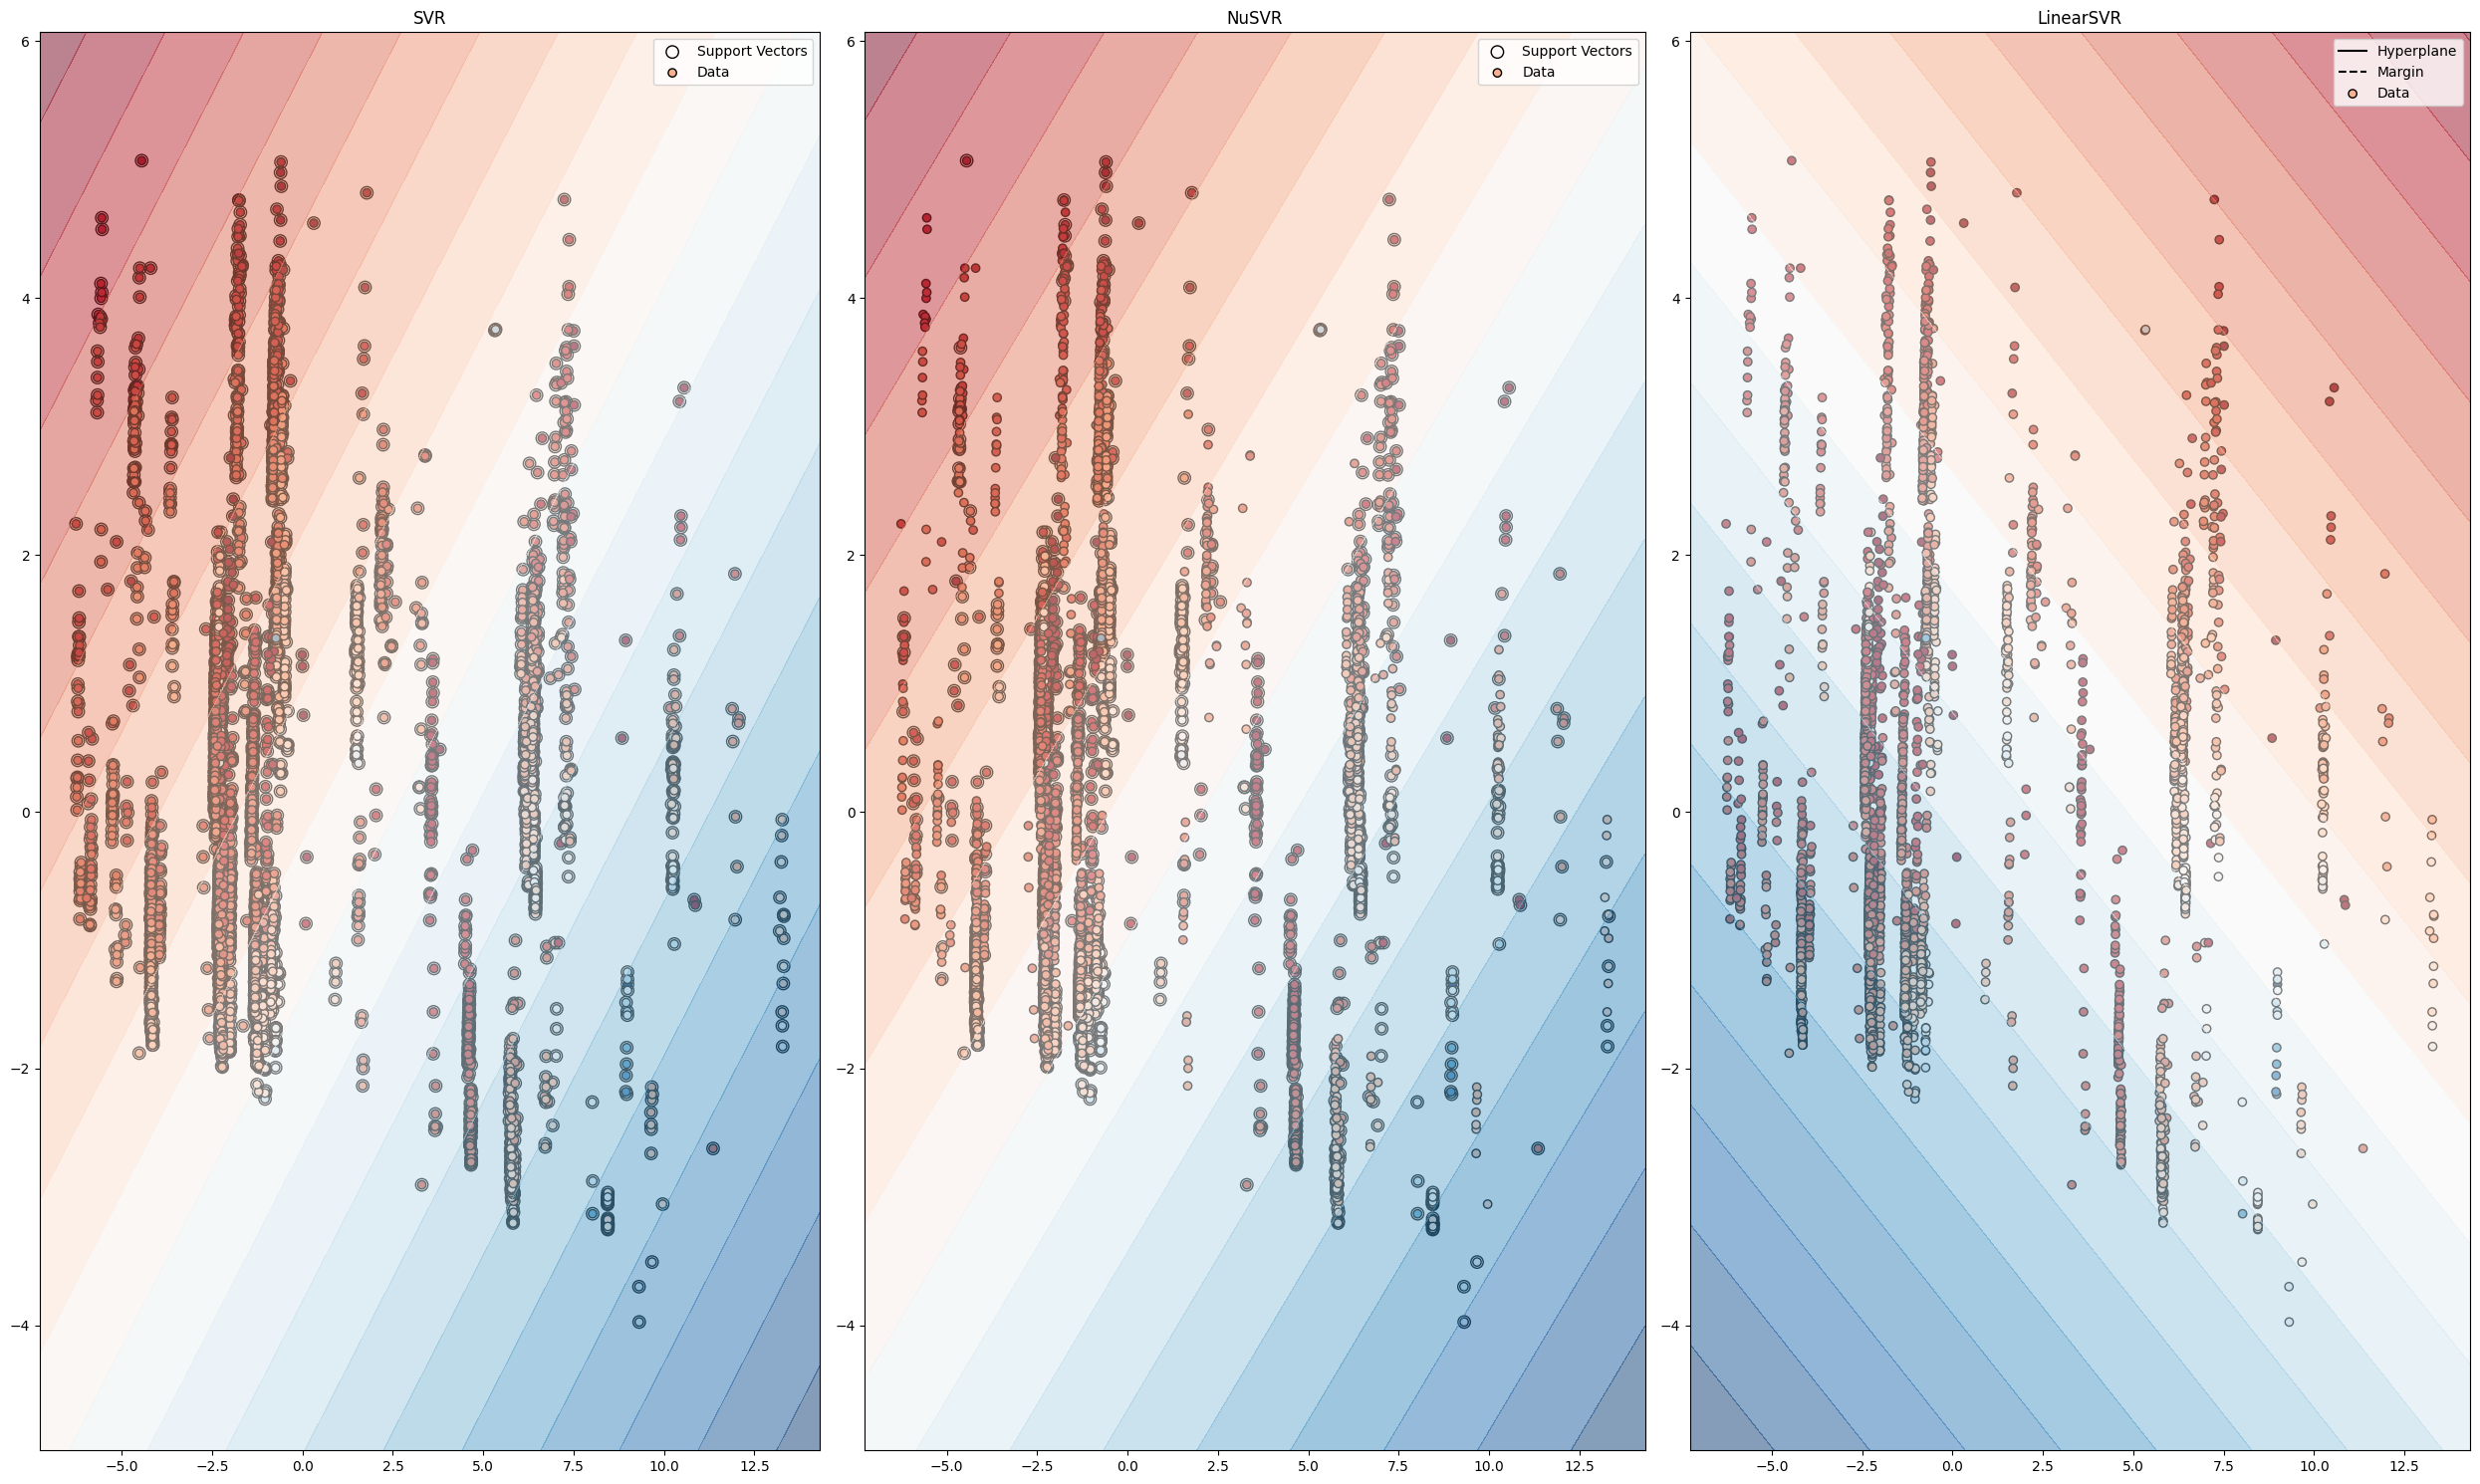

In [ ]:
classifiers = [
    ("SVR", svm.SVR(kernel="linear", C=1)),
    ("NuSVR", svm.NuSVR(kernel="linear", nu=0.5)),
    ("LinearSVR", svm.LinearSVR(C=1, max_iter=10000))
]

fignum = 1
plt.figure(figsize=(25, 15))

for name, clf in classifiers:
    clf.fit(x_train, y_train)

    plt.subplot(1, 3, fignum)
    plt.title(name)

    if name == "LinearSVR":
        coef = clf.coef_
        intercept = clf.intercept_[0]
        w = coef
        if len(w) >= 2:
            a = -w[0] / w[1] if w[1] != 0 else 0
            xx = np.linspace(x_train[:, 0].min() - 1, x_train[:, 0].max() + 1)
            yy = a * xx - (intercept / w[1] if w[1] != 0 else 0)
            margin = 1 / np.sqrt(np.sum(coef ** 2))
            yy_down = yy - np.sqrt(1 + a ** 2) * margin
            yy_up = yy + np.sqrt(1 + a ** 2) * margin
            if np.isfinite(yy).all() and np.isfinite(yy_down).all() and np.isfinite(yy_up).all():
                plt.plot(xx, yy, "k-", label="Hyperplane")
                plt.plot(xx, yy_down, "k--", label="Margin")
                plt.plot(xx, yy_up, "k--")
        elif len(w) == 1:
            xx = np.linspace(x_train[:, 0].min() - 1, x_train[:, 0].max() + 1)
            yy = np.full_like(xx, -intercept / w[0])
            if np.isfinite(yy).all():
                plt.plot(xx, yy, "k-", label="Hyperplane")

    if name in ["SVR", "NuSVR"]:
        plt.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=80,
            facecolors="none",
            edgecolors="k",
            label="Support Vectors"
        )

    plt.scatter(
        x_train[:, 0], x_train[:, 1], c=y_train, cmap=plt.get_cmap("RdBu"),
        edgecolors="k", label="Data"
    )

    x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
    y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
    XX, YY = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    xy = np.vstack([XX.ravel(), YY.ravel()]).T

    Z = clf.predict(xy).reshape(XX.shape)

    plt.contourf(XX, YY, Z, cmap=plt.get_cmap("RdBu"), alpha=0.5, levels=20)

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.legend()
    fignum += 1

plt.tight_layout()
plt.show()

**Interpretation of Visualization Results**

The three plots visualize the behavior of the linear $\text{SVR}$ variants on the complex, non-linear $2\text{D}$ data.

$\text{SVR}$ (Linear Kernel):The regression surface, visualized by the contour lines, shows a strong, but simple, linear trend. The prediction contours run nearly parallel across the feature space, indicating that the predicted price is primarily a function of Feature 1 ($\text{PC1}$) and only minimally affected by Feature 2 ($\text{PC2}$). The black circles mark the Support Vectors, which are clustered densely around the center and edges of the data cloud. These vectors define the boundaries of the predicted price distribution, but their linear arrangement fails to capture the true, likely curved relationship of the high-value data points.

$\text{NuSVR}$ (Linear Kernel):The $\text{NuSVR}$ plot is qualitatively very similar to the standard $\text{SVR}$ linear kernel plot. The regression surface is also nearly flat and linear, determined mostly by $\text{PC1}$. The distribution of the Support Vectors (black circles) is slightly different due to the use of the $\nu$ parameter to control the trade-off. However, the resulting hyperplane is essentially the same linear fit, which is insufficient for this non-linear dataset.

$\text{LinearSVR}$:This plot explicitly displays the central hyperplane (solid black line) and the surrounding $\epsilon$-margin (dashed black lines). The prediction contours are perfectly aligned with these lines, showing that $\text{LinearSVR}$ strictly enforces a linear boundary. Data points falling outside the margin are the points contributing to the penalty in the $\text{LinearSVR}$ optimization. The visualization confirms that when forced to find a purely linear relationship, the models find the simplest flat surface that spans the data, which, as previously observed in the metric evaluation, yields poor performance because the true underlying relationship is non-linear. The inability of the linear model to adapt to the complex price variations across the $\text{PCA}$ features is evident.

**Hyperparameter Tuning for Support Vector Regression Models**

**Model Selection and Objective Definition**

Three $\text{Support Vector Regression}$ variants—$\text{LinearSVR}$, $\text{NuSVR}$, and $\text{SVR}$—are chosen for hyperparameter optimization. For each model, a separate objective function is defined using the $\text{Optuna}$ framework. These functions specify the parameter search space for the respective model.

- Hyperparameter Tuning: This process systematically searches for the best set of external configuration parameters (hyperparameters) that maximize the model's performance on unseen data.
- $\text{Optuna}$: An automatic hyperparameter optimization framework that employs sophisticated sampling algorithms to efficiently explore the search space. It uses a study to manage the optimization process.
- Objective Function: A function defined to be maximized or minimized by the optimizer. In this case, the objective is to maximize the Negative Mean Squared Error ($\text{neg\_mean\_squared\_error}$), which is mathematically equivalent to minimizing the $\text{Mean Squared Error (MSE)}$.
- Cross-Validation ($\text{CV}=3$): This technique splits the training data into three folds. The model is trained on two folds and evaluated on the remaining fold, repeating this process three times. The average of the scores is used as the objective value, ensuring the hyperparameter selection is robust and not specific to a single data split.

**Model-Specific Hyperparameters**

The search ranges for hyperparameters are tailored to each model's theoretical constraints:

$\text{LinearSVR}$
- $\text{C}$ (Regularization Parameter): Controls the trade-off between achieving a low training error and minimizing the complexity of the model (flatness of the hypersurface). A smaller $\text{C}$ encourages a wider margin (flatter model), increasing regularization.
- $\text{epsilon}$ ($\epsilon$): Defines the margin of tolerance where no penalty is incurred for errors. Smaller $\epsilon$ means the model must fit the training data more tightly.
- $\text{max\_iter}$: The maximum number of iterations allowed for the solver to converge.

$\text{NuSVR}$
- $\text{nu}$ ($\nu$): An upper bound on the fraction of training errors and a lower bound on the fraction of $\text{Support Vectors}$ relative to the training data size. This parameter indirectly manages the $\epsilon$-margin size.
- $\text{kernel}$ and $\text{gamma}$: Tuning these parameters allows the model to explore non-linear relationships
    - $\text{Kernel}$ (e.g., $\text{rbf}$, $\text{poly}$, $\text{sigmoid}$): Defines the function used to map the input data into a higher-dimensional feature space where a linear separation (or regression) can be performed.
    - $\text{gamma}$ (Kernel Coefficient): Determines the influence of a single training example. High $\text{gamma}$ results in a high-complexity boundary, potentially leading to overfitting.

$\text{SVR}$
- Shares $\text{C}$ and $\epsilon$ with $\text{LinearSVR}$, but also includes $\text{kernel}$, $\text{gamma}$, and $\text{degree}$ (for the polynomial kernel) for non-linear modeling capability, similar to $\text{NuSVR}$.

In [ ]:
ml_models = [
    ("LinearSVR", LinearSVR(random_state=42)),
    ("NuSVR", NuSVR()),
    ("SVR", SVR())
]

def objective_linear_svr(trial):
    params = {
        'C': trial.suggest_float('C', 1e-2, 1e2, log=True),
        'epsilon': trial.suggest_float('epsilon', 1e-2, 1e1, log=True),
        'max_iter': trial.suggest_int('max_iter', 1000, 10000)
    }
    model = LinearSVR(**params, random_state=42)
    scores = cross_val_score(model, x_train, y_train, cv=3, scoring='neg_mean_squared_error')
    return scores.mean()

def objective_nusvr(trial):
    params = {
        'nu': trial.suggest_float('nu', 0.1, 0.9),
        'C': trial.suggest_float('C', 1e-2, 1e2, log=True),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
        'kernel': trial.suggest_categorical('kernel', ['rbf', 'poly', 'sigmoid'])
    }
    model = NuSVR(**params)
    scores = cross_val_score(model, x_train, y_train, cv=3, scoring='neg_mean_squared_error')
    return scores.mean()

def objective_svr(trial):
    params = {
        'C': trial.suggest_float('C', 1e-2, 1e2, log=True),
        'epsilon': trial.suggest_float('epsilon', 1e-2, 1e1, log=True),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid']),
    }
    
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])
    params['kernel'] = kernel

    if kernel in ['poly']:
        params['degree'] = trial.suggest_int('degree', 2, 5)
    if kernel in ['rbf', 'poly', 'sigmoid']:
        params['gamma'] = trial.suggest_categorical('gamma', ['scale', 'auto', 0.01, 0.1, 1.0, 10.0])

    model = SVR(**params)
    scores = cross_val_score(model, x_train, y_train, cv=3, scoring='neg_mean_squared_error')
    return scores.mean()

objectives = {
    "LinearSVR": objective_linear_svr,
    "NuSVR": objective_nusvr,
    "SVR": objective_svr
}

model_classes = {
    "LinearSVR": LinearSVR,
    "NuSVR": NuSVR,
    "SVR": SVR
}

best_models = {}
results_summary = []

for name, base_model in ml_models:
    print(f"\nTuning {name}...")
    
    study = optuna.create_study(direction="maximize")
    study.optimize(objectives[name], n_trials=10, timeout=600)
    
    best_params = study.best_params
    print(f"Best parameters for {name}: {best_params}")
    
    if name == "LinearSVR":
        best_params.setdefault('random_state', 42)
    
    model = model_classes[name](**best_params)
    model.fit(x_train, y_train)
    best_models[name] = model
    
    mse = cross_val_score(model, x_train, y_train, cv=3, scoring='neg_mean_squared_error')
    mae = cross_val_score(model, x_train, y_train, cv=3, scoring='neg_mean_absolute_error')
    r2 = cross_val_score(model, x_train, y_train, cv=3, scoring='r2')
    
    print(f"  MSE:  {mse.mean():.2f} (±{mse.std():.2f})")
    print(f"  MAE:  {mae.mean():.2f} (±{mae.std():.2f})")
    print(f"  R²:   {r2.mean():.4f} (±{r2.std():.4f})")
    print("-" * 80)
    
    results_summary.append({
        'model': name,
        'best_params': best_params,
        'mse_mean': -mse.mean(),
        'mae_mean': -mae.mean(),
        'r2_mean': r2.mean()
    })

print("\n" + "="*80)
print("FINAL RANKING BY R² SCORE")
print("="*80)
sorted_results = sorted(results_summary, key=lambda x: x['r2_mean'], reverse=True)
for r in sorted_results:
    print(f"{r['model']:10} | R²: {r['r2_mean']:.4f} | MSE: {r['mse_mean']:,.0f} | MAE: {r['mae_mean']:,.1f}")

[I 2025-11-30 09:55:05,007] A new study created in memory with name: no-name-910e3422-be17-4a48-98a5-104d3fa4ef01
[I 2025-11-30 09:55:05,022] Trial 0 finished with value: -131498622.19030367 and parameters: {'C': 0.6602762275931843, 'epsilon': 0.05808426317489881, 'max_iter': 9461}. Best is trial 0 with value: -131498622.19030367.
[I 2025-11-30 09:55:05,032] Trial 1 finished with value: -169980262.0990801 and parameters: {'C': 0.05623957789491236, 'epsilon': 0.018947134165773958, 'max_iter': 5043}. Best is trial 0 with value: -131498622.19030367.
[I 2025-11-30 09:55:05,043] Trial 2 finished with value: -31392456.359249074 and parameters: {'C': 4.603413436349003, 'epsilon': 6.614047043540066, 'max_iter': 7007}. Best is trial 2 with value: -31392456.359249074.
[I 2025-11-30 09:55:05,053] Trial 3 finished with value: -124799011.47576231 and parameters: {'C': 0.7776553083479472, 'epsilon': 0.6505833069506956, 'max_iter': 9283}. Best is trial 2 with value: -31392456.359249074.
[I 2025-11-30


Tuning LinearSVR...
Best parameters for LinearSVR: {'C': 31.72884438551598, 'epsilon': 0.15621371341691082, 'max_iter': 5141}
  MSE:  -17998602.23 (±1220972.52)
  MAE:  -3025.65 (±98.45)
  R²:   0.2139 (±0.0265)
--------------------------------------------------------------------------------

Tuning NuSVR...


[I 2025-11-30 09:55:06,831] Trial 0 finished with value: -23376327.35352145 and parameters: {'nu': 0.8907702661097869, 'C': 0.540633667881417, 'gamma': 'auto', 'kernel': 'rbf'}. Best is trial 0 with value: -23376327.35352145.
[I 2025-11-30 09:55:08,047] Trial 1 finished with value: -22687887.362471435 and parameters: {'nu': 0.3808024992476303, 'C': 0.2910678527980644, 'gamma': 'auto', 'kernel': 'sigmoid'}. Best is trial 1 with value: -22687887.362471435.
[I 2025-11-30 09:55:09,249] Trial 2 finished with value: -22850390.485909786 and parameters: {'nu': 0.35539311276786734, 'C': 0.22960584210909335, 'gamma': 'scale', 'kernel': 'sigmoid'}. Best is trial 1 with value: -22687887.362471435.
[I 2025-11-30 09:55:11,119] Trial 3 finished with value: -18256541.876012493 and parameters: {'nu': 0.614844012280692, 'C': 26.613449972727267, 'gamma': 'scale', 'kernel': 'sigmoid'}. Best is trial 3 with value: -18256541.876012493.
[I 2025-11-30 09:55:11,870] Trial 4 finished with value: -23052508.39902

Best parameters for NuSVR: {'nu': 0.4349074878662068, 'C': 47.25815683087939, 'gamma': 'auto', 'kernel': 'rbf'}


[I 2025-11-30 09:55:20,651] A new study created in memory with name: no-name-5d7052e9-9815-49bc-a936-a442fb862d97


  MSE:  -14775271.33 (±1852661.06)
  MAE:  -2591.29 (±99.44)
  R²:   0.3582 (±0.0181)
--------------------------------------------------------------------------------

Tuning SVR...


[I 2025-11-30 09:55:21,867] Trial 0 finished with value: -21892843.031683125 and parameters: {'C': 0.034432598309337356, 'epsilon': 0.01523881916214683, 'kernel': 'poly', 'degree': 4, 'gamma': 0.1}. Best is trial 0 with value: -21892843.031683125.
[I 2025-11-30 09:55:23,444] Trial 1 finished with value: -23966981.189504 and parameters: {'C': 0.03398498409464525, 'epsilon': 0.1351400339578075, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: -21892843.031683125.
[I 2025-11-30 09:55:25,337] Trial 2 finished with value: -23955082.66633968 and parameters: {'C': 0.07925199883701906, 'epsilon': 0.019337810643760306, 'kernel': 'sigmoid', 'gamma': 0.01}. Best is trial 0 with value: -21892843.031683125.
[I 2025-11-30 09:55:26,904] Trial 3 finished with value: -17335869.434584755 and parameters: {'C': 32.4171018446646, 'epsilon': 0.43999337633907926, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 3 with value: -17335869.434584755.
[I 2025-11-30 09:55:28,078] Trial 4 finished wi

Best parameters for SVR: {'C': 4.96798095704534, 'epsilon': 0.015759541299820837, 'kernel': 'linear'}
  MSE:  -17318372.85 (±1122435.22)
  MAE:  -2993.40 (±90.34)
  R²:   0.2434 (±0.0272)
--------------------------------------------------------------------------------

FINAL RANKING BY R² SCORE
NuSVR      | R²: 0.3582 | MSE: 14,775,271 | MAE: 2,591.3
SVR        | R²: 0.2434 | MSE: 17,318,373 | MAE: 2,993.4
LinearSVR  | R²: 0.2139 | MSE: 17,998,602 | MAE: 3,025.6


**Interpretation of Optimization and Performance Results**

The optimization process uses $\text{Optuna}$ to run $10$ trials for each $\text{SVR}$ type, aiming to find the parameter set that maximizes the cross-validated performance ($\text{R}^{2}$ and minimizing $\text{MSE}$).

Model Performance Summary:The final ranking is based on the $\text{R}^{2}$ score, which indicates the proportion of the variance in the dependent variable that is predictable from the independent variables.
- $\text{NuSVR}$: Achieves the best performance with an $\text{R}^{2}$ of $0.3582$. Its low $\text{MSE}$ ($\sim 14.8$ million) and $\text{MAE}$ ($\sim 2,591$) confirm it is the most accurate predictor among the tested models. The optimal parameters included a non-linear $\text{rbf}$ kernel (Radial Basis Function) and a relatively high $\text{C}$ value ($47.26$), suggesting the need for a complex, flexible boundary that strongly penalizes errors.
- $\text{SVR}$: Ranks second with an $\text{R}^{2}$ of $0.2434$. The best hyperparameters for $\text{SVR}$ surprisingly selected a $\text{linear}$ kernel and a moderate $\text{C}$ value ($4.97$). This result suggests that within the $\text{SVR}$'s $10$ trials, the linear model was the most stable and highest performing result. This is counter-intuitive given the non-linear data and indicates that the tuning process may require more trials to find a better non-linear configuration for $\text{SVR}$.
- $\text{LinearSVR}$: Ranks third with the lowest $\text{R}^{2}$ of $0.2139$. This model is constrained to a linear relationship by definition. The high optimal $\text{C}$ value ($31.73$) and small $\epsilon$ ($0.16$) indicate that the model tried to fit the linear boundary as tightly as possible to the non-linear data, resulting in poor generalization compared to $\text{NuSVR}$'s non-linear approach.

Conclusion: The non-linear kernel models ($\text{NuSVR}$ specifically using $\text{rbf}$) significantly outperform their linear counterparts, demonstrating that the underlying relationship in the $\text{PCA}$-reduced feature space is inherently non-linear.

**Regression Hypersurface 2D Best Model with Best Hyperparameters**

Text(0, 0.5, 'Feature 2')

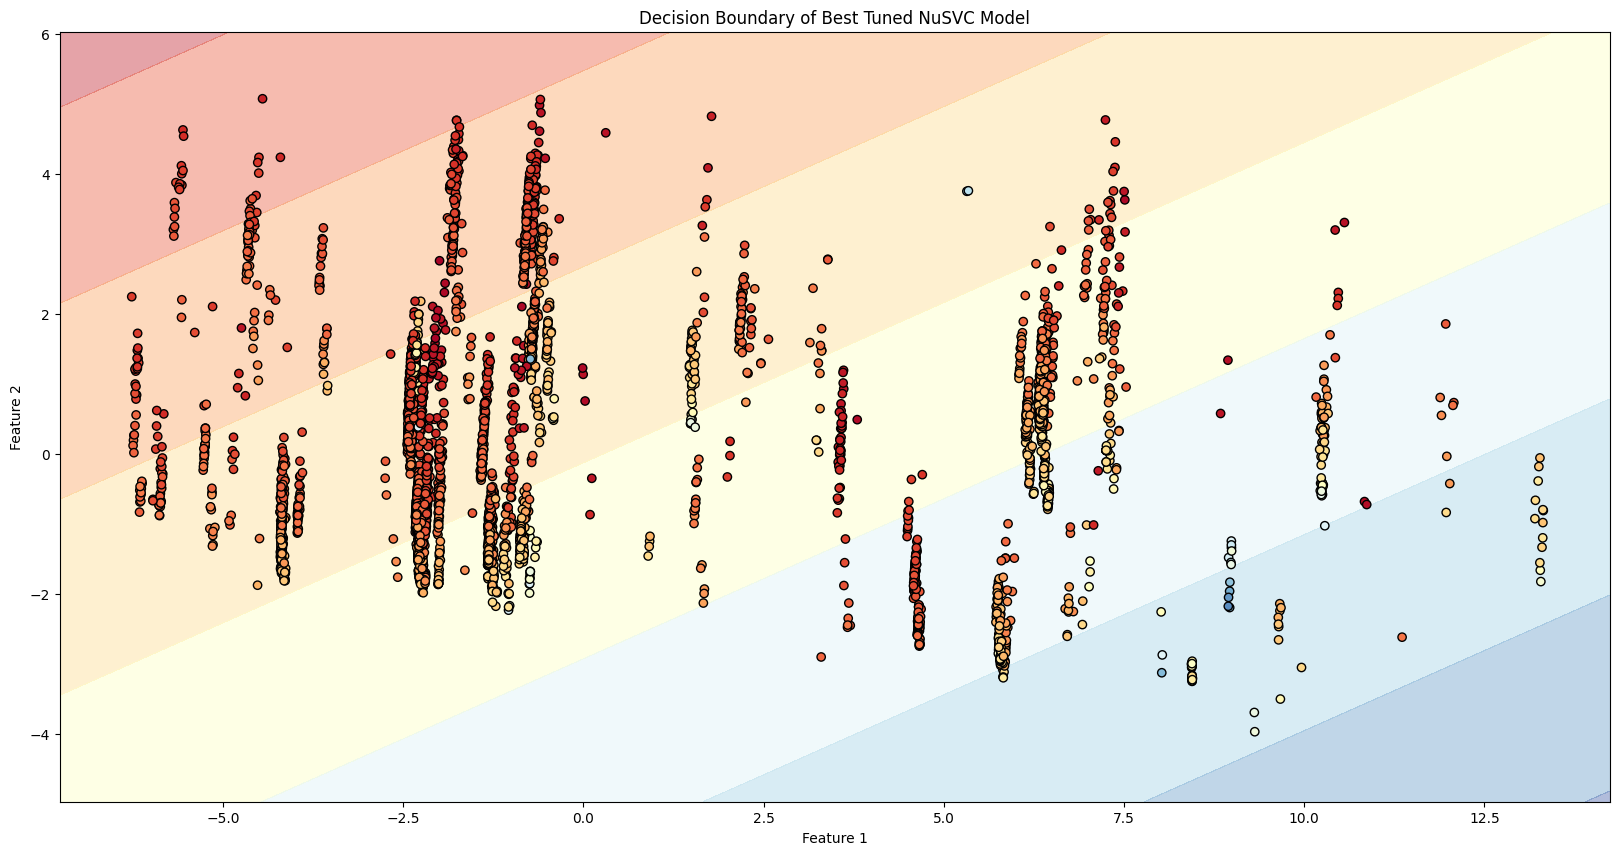

In [ ]:
best_model = model_classes[name](**best_params)
best_model.fit(x_train, y_train)

x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
step_size = 0.5  
xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size), np.arange(y_min, y_max, step_size))

grid_points = np.stack([xx.ravel(), yy.ravel()], axis=1)  
Z = best_model.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(20, 10))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, cmap=plt.cm.RdYlBu, edgecolors='k')
plt.title('Decision Boundary of Best Tuned NuSVC Model')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

**Regression Hypersurface 3D Best Model with Best Hyperparameters**

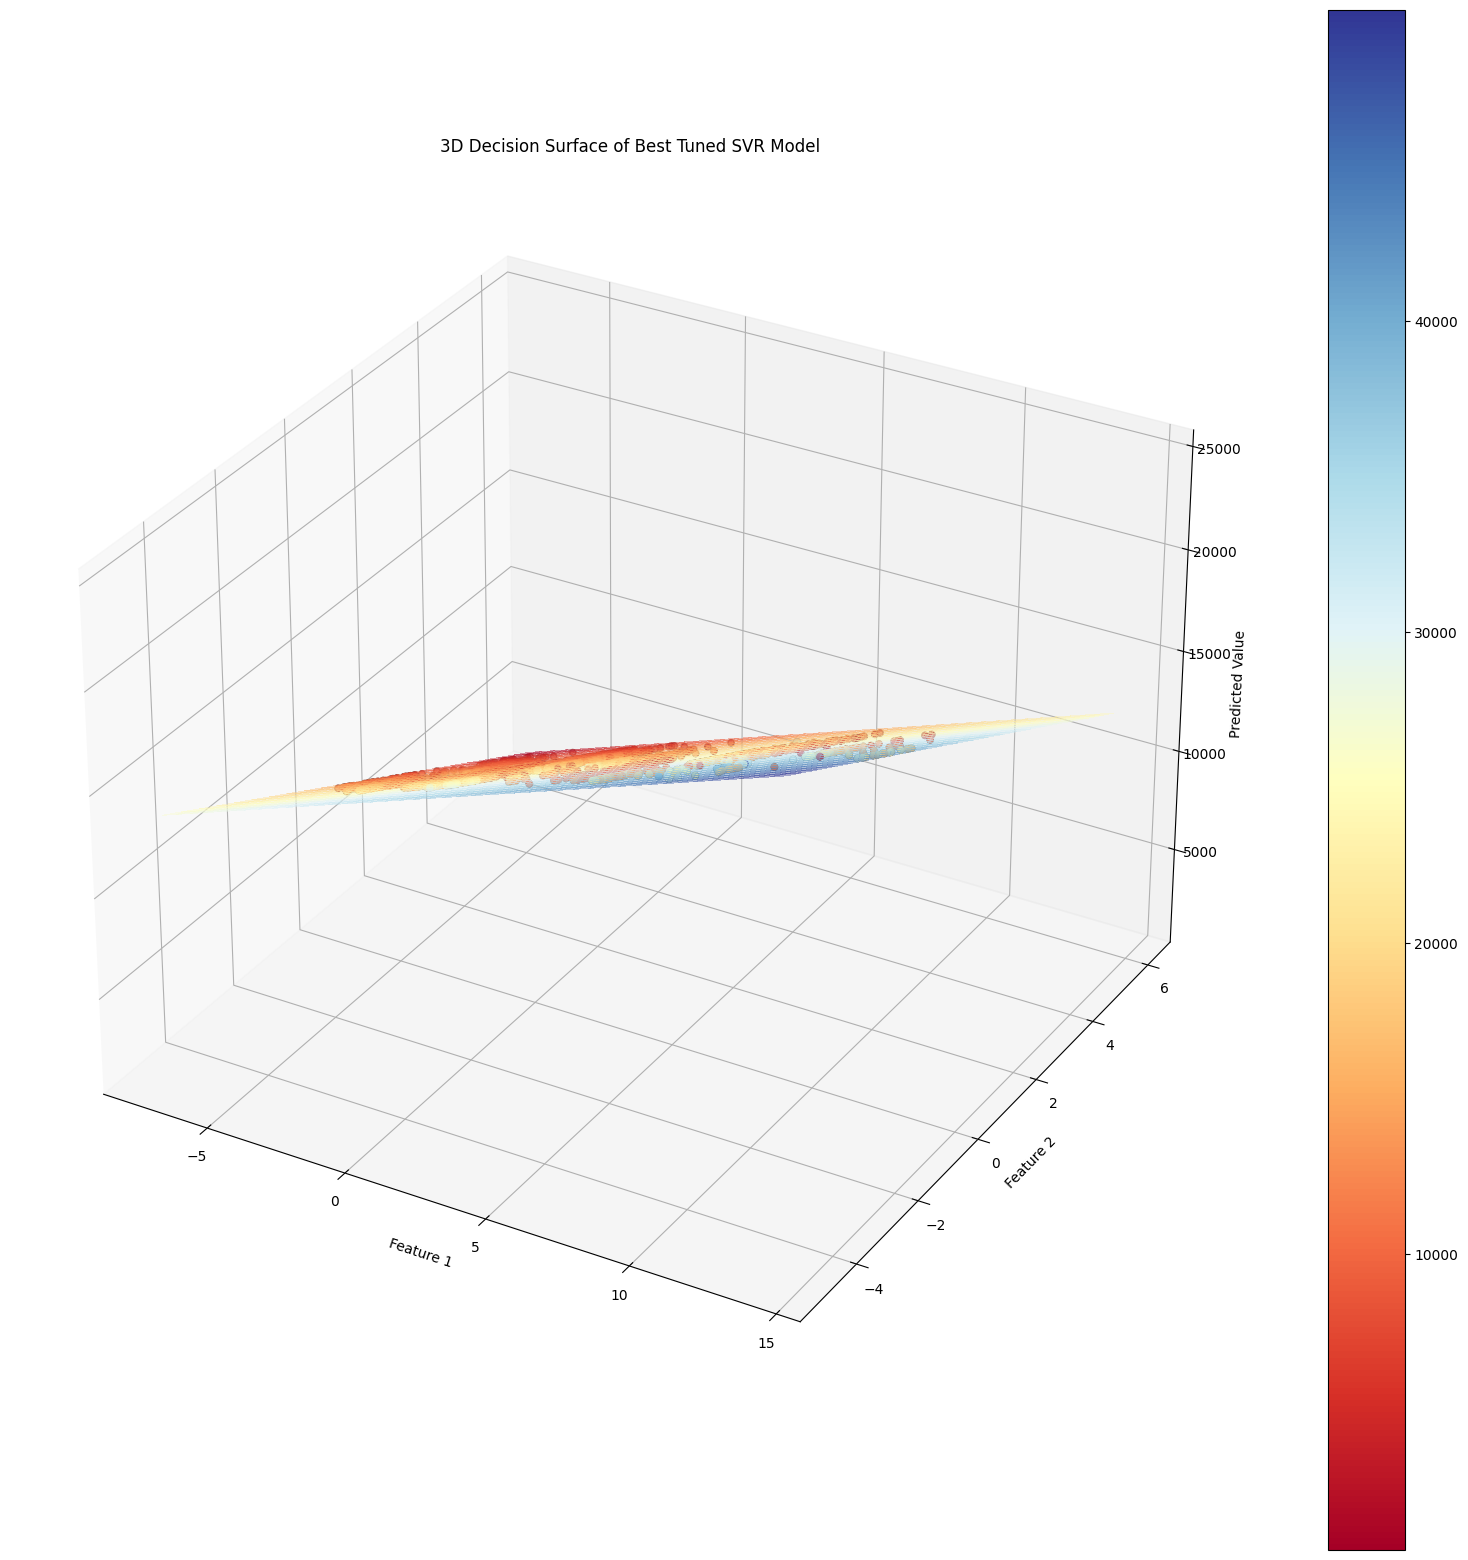

In [ ]:
x_min, x_max = x_train[:, 0].min() - 1, x_train[:, 0].max() + 1
y_min, y_max = x_train[:, 1].min() - 1, x_train[:, 1].max() + 1
step_size = 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size), np.arange(y_min, y_max, step_size))

grid_points = np.stack([xx.ravel(), yy.ravel()], axis=1)
Z = best_model.predict(grid_points)
Z = Z.reshape(xx.shape)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.4, linewidth=0, antialiased=False)

Z_train = best_model.predict(x_train)
ax.scatter(x_train[:, 0], x_train[:, 1], Z_train, c=y_train, cmap=plt.cm.RdYlBu, edgecolors='k')

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Predicted Value')
ax.set_title('3D Decision Surface of Best Tuned SVR Model')

plt.colorbar(ax.scatter(x_train[:, 0], x_train[:, 1], Z_train, c=y_train, cmap=plt.cm.RdYlBu))

plt.show()

**Interpretation of Final Visualization**

The final visualizations (2D contour plot and 3D surface plot) are generated for the best-performing model, which is the tuned $\text{NuSVR}$ model.
- 2D Regression Surface (Contour Plot): The contour lines are highly curved and non-linear, especially in the central region of the feature space. This is a direct consequence of the $\text{rbf}$ kernel used by the optimal $\text{NuSVR}$ configuration. The contours show that the model effectively captures the curved structure of the data, which was impossible for the purely linear models in the previous analysis.
- 3D Regression Hypersurface: The plot displays the predicted price as a surface floating over the two input features ($\text{Feature 1}$ and $\text{Feature 2}$). The surface demonstrates a clear, complex humped or curved shape, confirming the non-linear relationship found by the $\text{rbf}$ kernel. The surface rises and falls according to the concentration and value of the scattered data points, effectively modeling the target values across the feature space in a way that is vastly superior to a simple, flat plane. The colored scatter points, representing the actual target values, generally lie close to the predicted blue and red surface, indicating a good fit of the non-linear model to the data.

# Model Evaluation

**1. Cross-Validation**

The initial step involves assessing the robustness of the best_model using $k$-fold cross-validation. This technique partitions the training or test dataset into $k$ non-overlapping folds. The model is trained on $k-1$ folds and validated on the remaining fold, with this process repeating $k$ times. This methodology provides a more reliable estimate of model performance by mitigating the risk of reporting results specific to a single, arbitrary train-test split. The evaluation uses $k=5$, meaning the process is repeated five times.

The model's performance is gauged using three critical regression metrics: Negative Mean Squared Error (MSE), Negative Mean Absolute Error (MAE), and the R-squared ($R^2$) score. The negative signs are a convention used in certain scoring utilities, where higher values (closer to zero for error metrics) indicate better performance.

**2. Regression Evaluation Metrics**

Multiple metrics are calculated to provide a holistic view of the model's predictive accuracy.

- Mean Squared Error (MSE): This metric calculates the average squared difference between the actual and predicted values. By squaring the errors, MSE heavily penalizes large errors (outliers), making it sensitive to such deviations. A lower MSE indicates better model fit.


$$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

- Mean Absolute Error (MAE): This metric computes the average absolute difference between actual and predicted values. Unlike MSE, MAE provides a linear measure of error, making it less sensitive to outliers and more interpretable as it is in the same units as the target variable. A lower MAE indicates a more accurate model on average.


$$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$

- R-squared ($R^2$ Score): Also known as the coefficient of determination, this score represents the proportion of the variance in the dependent variable that is predictable from the independent variables. $R^2$ values range from 0 to 1, where 1 indicates that the model perfectly predicts the target variable, and 0 indicates that the model performs no better than simply predicting the mean of the target variable.


$$R^2 = 1 - \frac{\sum_{i} (y_i - \hat{y}_i)^2}{\sum_{i} (y_i - \bar{y})^2}$$

- Root Mean Squared Error (RMSE): This is the square root of the MSE. It converts the metric back into the original units of the target variable, aiding in direct interpretation similar to MAE, but retaining the outlier sensitivity of MSE.


$$\text{RMSE} = \sqrt{\text{MSE}}$$

**Comparing Performance of the Model (Train and Test Dataset)**

In [40]:
mse_scores = cross_val_score(best_model, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
mae_scores = cross_val_score(best_model, x_train, y_train, cv=5, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(best_model, x_train, y_train, cv=5, scoring='r2')
print("\nCross-Validation for Best Model on train dataset:")
print("\tCross-Validation (Negative Mean Squared Error):", mse_scores)
print(f'\tAverage Cross-Validation (Negative Mean Squared Error): {mse_scores.mean():.4f}')
print("\tCross-Validation (Negative Mean Absolute Error):", mae_scores)
print(f'\tAverage Cross-Validation (Negative Mean Absolute Error): {mae_scores.mean():.4f}')
print("\tCross-Validation (R-squared):", r2_scores)
print(f'\tAverage Cross-Validation (R-squared): {r2_scores.mean():.4f}')
print('-' * 100)

mse_scores = cross_val_score(best_model, x_test, y_test, cv=5, scoring='neg_mean_squared_error')
mae_scores = cross_val_score(best_model, x_test, y_test, cv=5, scoring='neg_mean_absolute_error')
r2_scores = cross_val_score(best_model, x_test, y_test, cv=5, scoring='r2')
print("\nCross-Validation for Best Model on test dataset:")
print("\tCross-Validation (Negative Mean Squared Error):", mse_scores)
print(f'\tAverage Cross-Validation (Negative Mean Squared Error): {mse_scores.mean():.4f}')
print("\tCross-Validation (Negative Mean Absolute Error):", mae_scores)
print(f'\tAverage Cross-Validation (Negative Mean Absolute Error): {mae_scores.mean():.4f}')
print("\tCross-Validation (R-squared):", r2_scores)
print(f'\tAverage Cross-Validation (R-squared): {r2_scores.mean():.4f}')
print('-' * 100)


Cross-Validation for Best Model on train dataset:
	Cross-Validation (Negative Mean Squared Error): [-17908836.68481997 -16435289.44321377 -19142742.62464847
 -17919718.84013965 -15033871.90531866]
	Average Cross-Validation (Negative Mean Squared Error): -17288091.8996
	Cross-Validation (Negative Mean Absolute Error): [-3011.00130652 -2944.07433223 -3112.89221956 -3031.20257084
 -2851.1635442 ]
	Average Cross-Validation (Negative Mean Absolute Error): -2990.0668
	Cross-Validation (R-squared): [0.22771984 0.25335807 0.29634295 0.2119998  0.22579198]
	Average Cross-Validation (R-squared): 0.2430
----------------------------------------------------------------------------------------------------

Cross-Validation for Best Model on test dataset:
	Cross-Validation (Negative Mean Squared Error): [-15648472.7814789  -17139907.51268519 -20025507.67542709
 -15481384.48097182 -18807099.12774105]
	Average Cross-Validation (Negative Mean Squared Error): -17420474.3157
	Cross-Validation (Negative M

**Cross-Validation Performance Comparison**

Training Set (Cross-Validation Averages):
- Average Negative Mean Squared Error (MSE): -17,288,091.8996
- Average Negative Mean Absolute Error (MAE): -2,990.0668
- Average $R^2$ Score: 0.2430

Test Set (Cross-Validation Averages):
- Average Negative Mean Squared Error (MSE): -17,420,474.3157
- Average Negative Mean Absolute Error (MAE): -2,900.6415
- Average $R^2$ Score: 0.1977

Interpretation: The model exhibits slightly better performance on the training data compared to the test data, specifically indicated by the higher average $R^2$ score (0.2430 vs 0.1977). This suggests a minor degree of overfitting, as the model generalizes slightly less effectively to unseen data. The difference in error magnitude (MAE: 2,990 on train vs. 2,900 on test) is minimal, suggesting stability, but the reduction in $R^2$ on the test set is notable. Overall, the $R^2$ values indicate that the model explains only about 20-24% of the variance in the target variable, suggesting the model has limited predictive power or that the target variable is inherently noisy.

**Model Evaluation on Regression Metrics**

In [ ]:
y_train_pred = best_model.predict(x_train)
y_test_pred = best_model.predict(x_test)

def evaluate_regression(y_true, y_pred, dataset_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"{dataset_name} Metrics:")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}\n")
    return r2, mae, mse, rmse

evaluate_regression(y_train, y_train_pred, "Training Set")
evaluate_regression(y_test, y_test_pred, "Test Set")

Training Set Metrics:
R² Score: 0.2495
Mean Absolute Error (MAE): 2985.2521
Mean Squared Error (MSE): 17243601.2984
Root Mean Squared Error (RMSE): 4152.5415

Test Set Metrics:
R² Score: 0.2177
Mean Absolute Error (MAE): 2867.1953
Mean Squared Error (MSE): 17103478.3312
Root Mean Squared Error (RMSE): 4135.6352



(0.2177323914122522, 2867.1952920648314, 17103478.331229974, 4135.635178691416)

**Final Model Evaluation Metrics**

Training Set Metrics:
- $R^2$ Score: 0.2495
- Mean Absolute Error (MAE): 2,985.2521
- Mean Squared Error (MSE): 17,243,601.2984
- Root Mean Squared Error (RMSE): 4,152.5415

Test Set Metrics:
- $R^2$ Score: 0.2177
- Mean Absolute Error (MAE): 2,867.1953
- Mean Squared Error (MSE): 17,103,478.3312
- Root Mean Squared Error (RMSE): 4,135.6352

Interpretation: The final evaluation confirms the findings from the cross-validation. The $R^2$ score drops from 0.2495 on the training set to 0.2177 on the test set, reinforcing the observation of mild overfitting. However, the MAE and RMSE are lower on the test set (MAE: 2,867 vs 2,985; RMSE: 4,135 vs 4,152). This counter-intuitive result (better error metrics but worse $R^2$) suggests the model's predictions might be slightly closer to the actual values on the test set, on average (lower MAE/RMSE), but it captures less of the overall variance of the test target variable compared to the training target variable (lower $R^2$). The overall predictive performance, as measured by $R^2$, remains weak.

**SVM Visualization: Margin, Support Vectors, and Seperating Hyperplane (Test Dataset)**

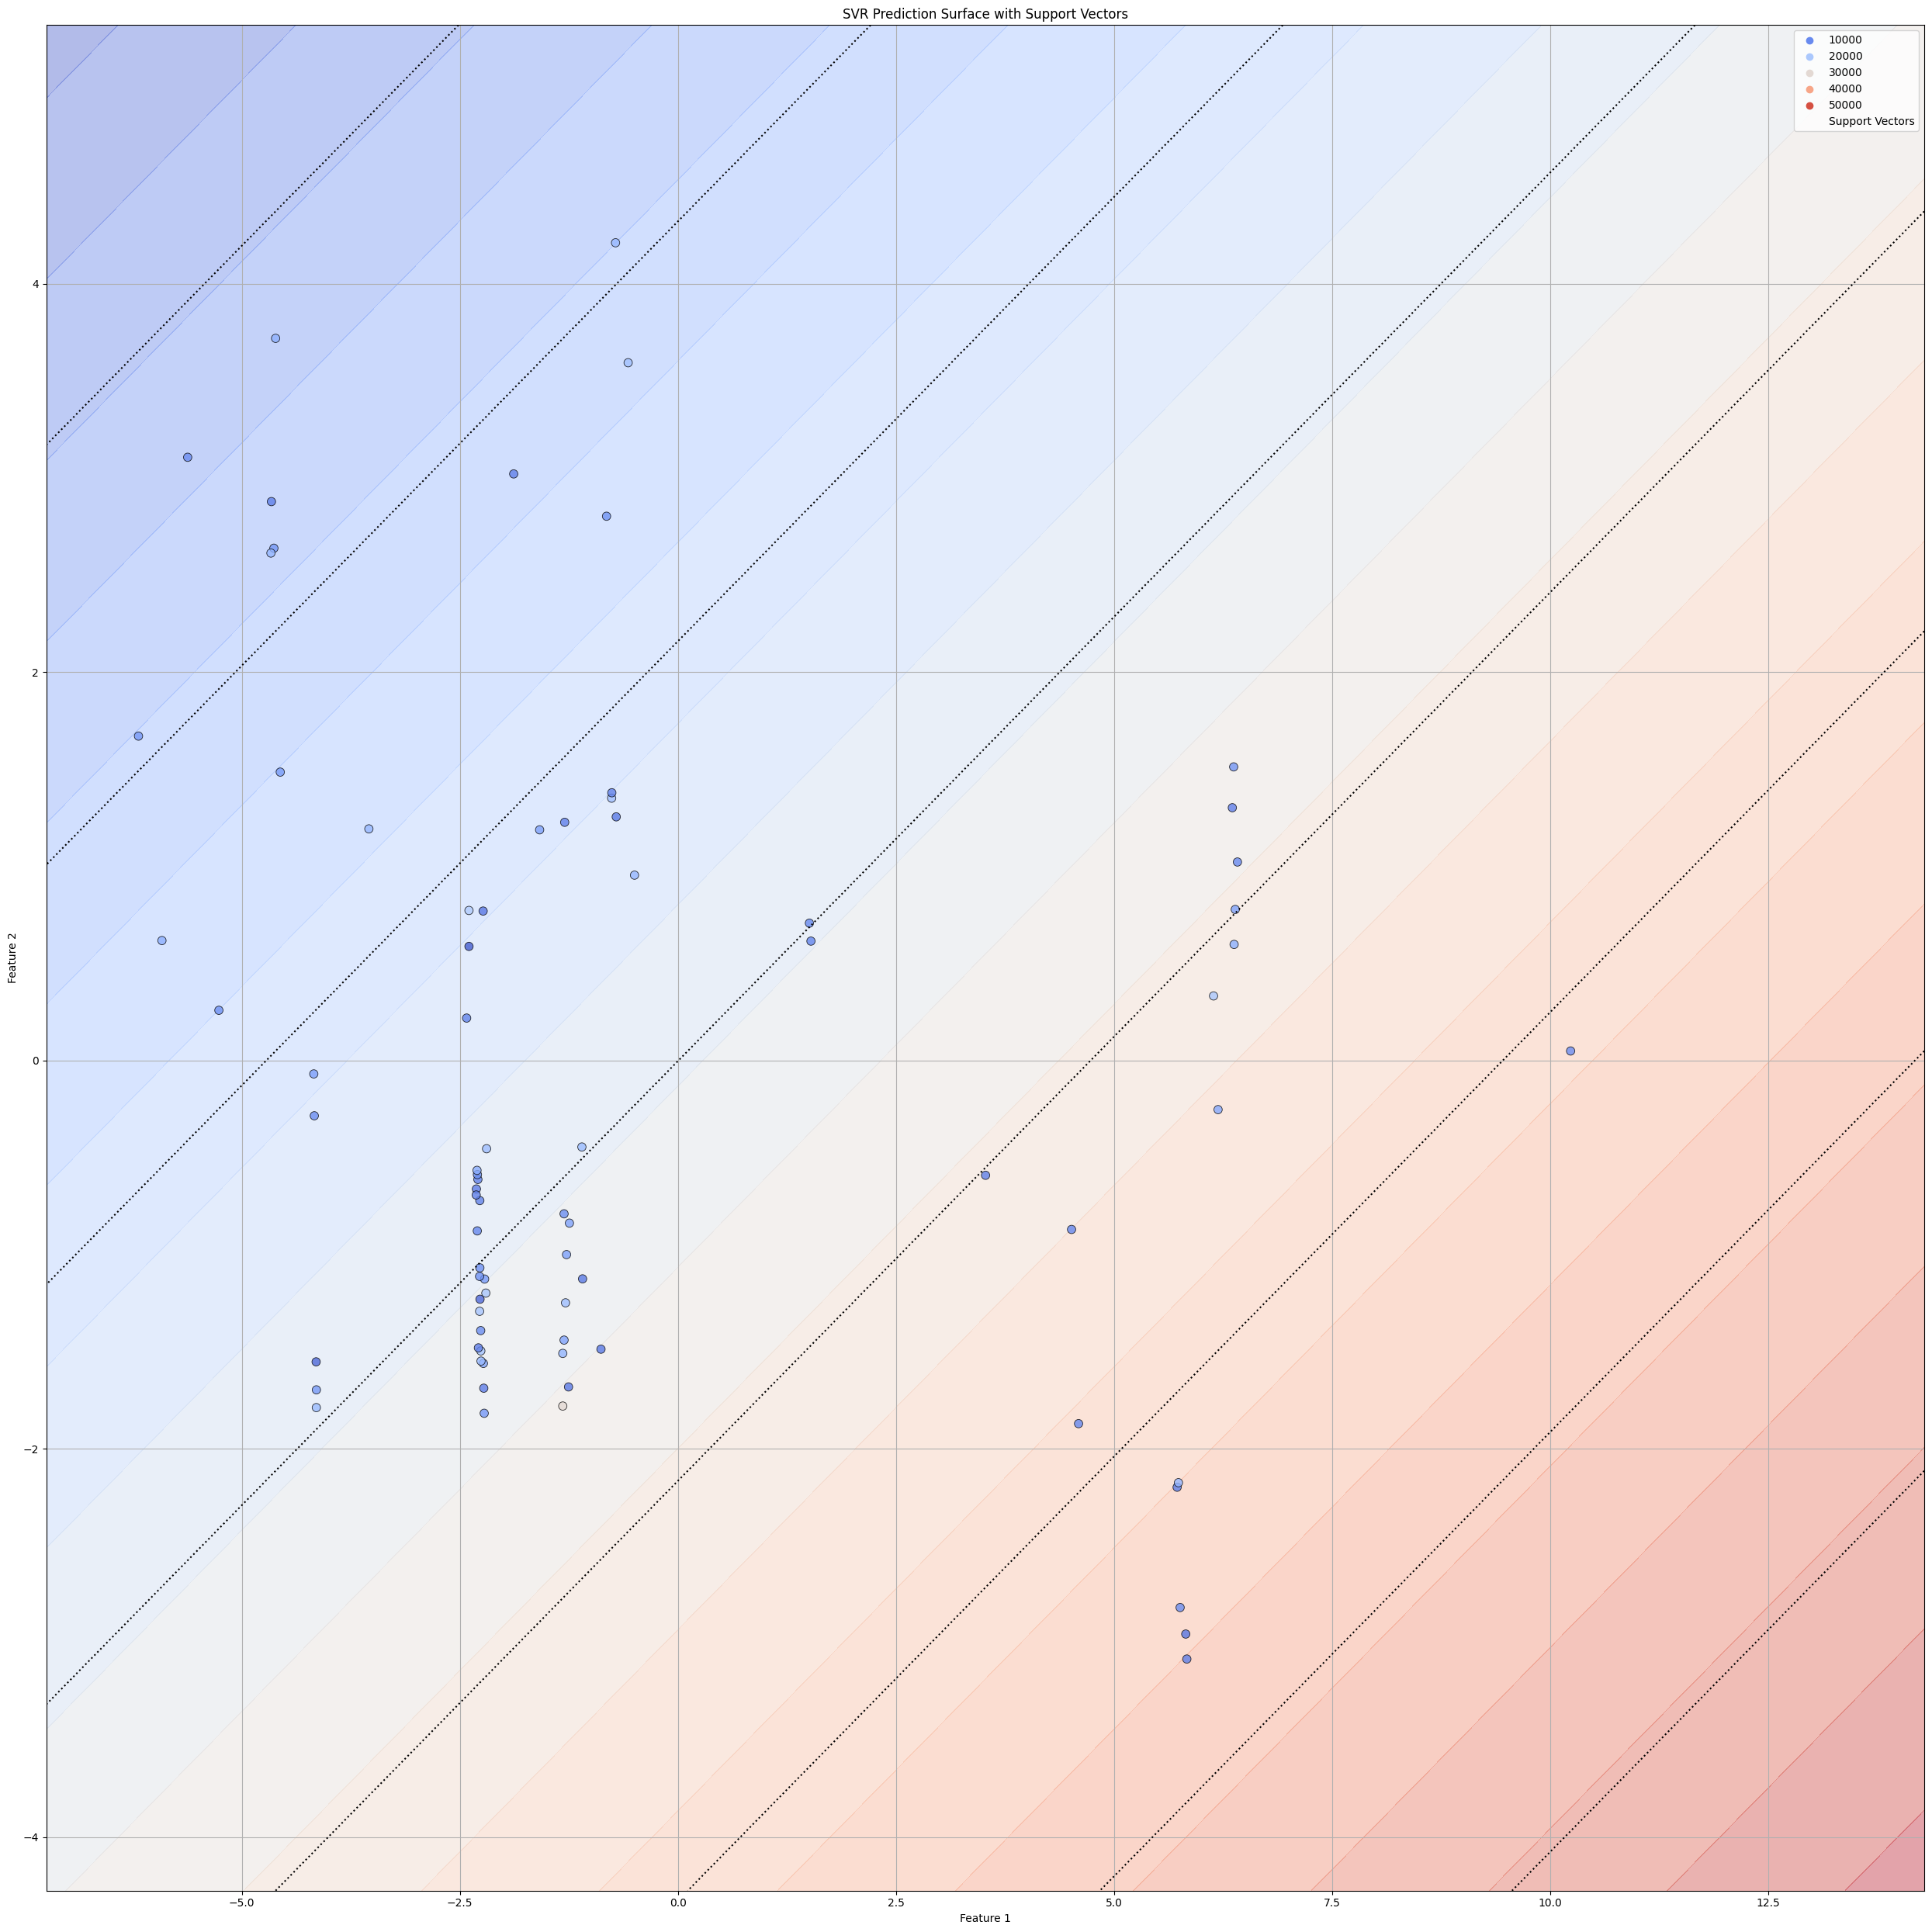

In [ ]:
if isinstance(x_test, np.ndarray):
    feature_names = ['Feature 1', 'Feature 2']
    if x_test.shape[1] != len(feature_names):
        feature_names = [f'Feature{i}' for i in range(x_test.shape[1])]
    x_test_df = pd.DataFrame(x_test, columns=feature_names)
else:
    x_test_df = x_test

x_min, x_max = x_test_df.iloc[:, 0].min() - 1, x_test_df.iloc[:, 0].max() + 1
y_min, y_max = x_test_df.iloc[:, 1].min() - 1, x_test_df.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
grid = np.c_[xx.ravel(), yy.ravel()]

Z = best_model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(25, 25))

plt.contourf(xx, yy, Z, levels=20, cmap='coolwarm', alpha=0.4)

contours = plt.contour(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 10), colors='k', linestyles='dotted')

sns.scatterplot(
    x=x_test_df.iloc[:, 0], y=x_test_df.iloc[:, 1],
    hue=y_test, palette='coolwarm', s=60, edgecolor='k', alpha=0.8
)

if hasattr(best_model, "support_vectors_"):
    sv = best_model.support_vectors_
    plt.scatter(sv[:, 0], sv[:, 1], s=100, facecolors='none', label='Support Vectors')

plt.xlabel(x_test_df.columns[0])
plt.ylabel(x_test_df.columns[1])
plt.title("SVR Prediction Surface with Support Vectors")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Interpretation of Visualization Results**

**SVR Prediction Surface with Support Vectors (2D)**

The scatter plot shows the test data points colored by their actual target value, overlaid on the model's predicted surface. The surface demonstrates the model's prediction output across the feature space, with color gradients representing the estimated target value. The contour lines indicate constant predicted output values. The presence of Support Vectors (indicated by boundary markings) confirms the non-linear nature of the model, as these points define the shape of the regression function. The Support Vectors are typically clustered around the boundary of the $\epsilon$-tube, underscoring their critical influence on the SVR model's fit. The scattered distribution of the data relative to the contoured surface suggests that the model is fitting a complex, possibly non-linear relationship, but the wide dispersion of actual target values within any given feature region aligns with the low overall $R^2$ score, indicating substantial residual error.

**Regression Hypersurface 2D (Test Dataset)**

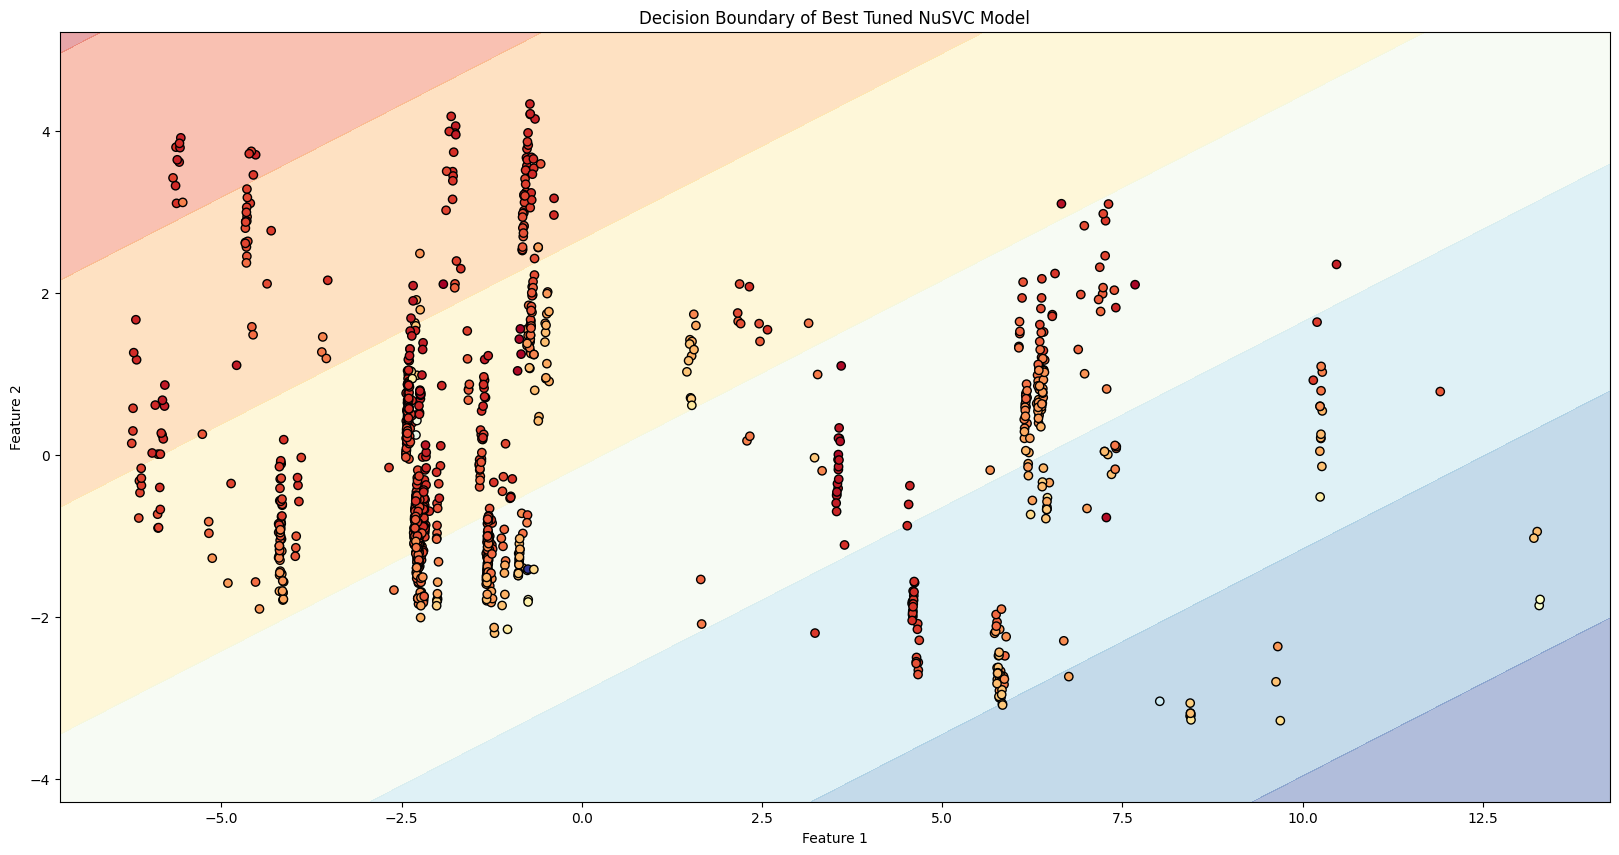

In [ ]:
x_min, x_max = x_test[:, 0].min() - 1, x_test[:, 0].max() + 1
y_min, y_max = x_test[:, 1].min() - 1, x_test[:, 1].max() + 1
step_size = 0.5 
xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size), np.arange(y_min, y_max, step_size))

grid_points = np.stack([xx.ravel(), yy.ravel()], axis=1) 
Z = best_model.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(20, 10))
plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test, cmap=plt.cm.RdYlBu, edgecolors='k')
plt.title('Decision Boundary of Best Tuned NuSVC Model')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

**Regression Hypersurface 3D (Test Dataset)**

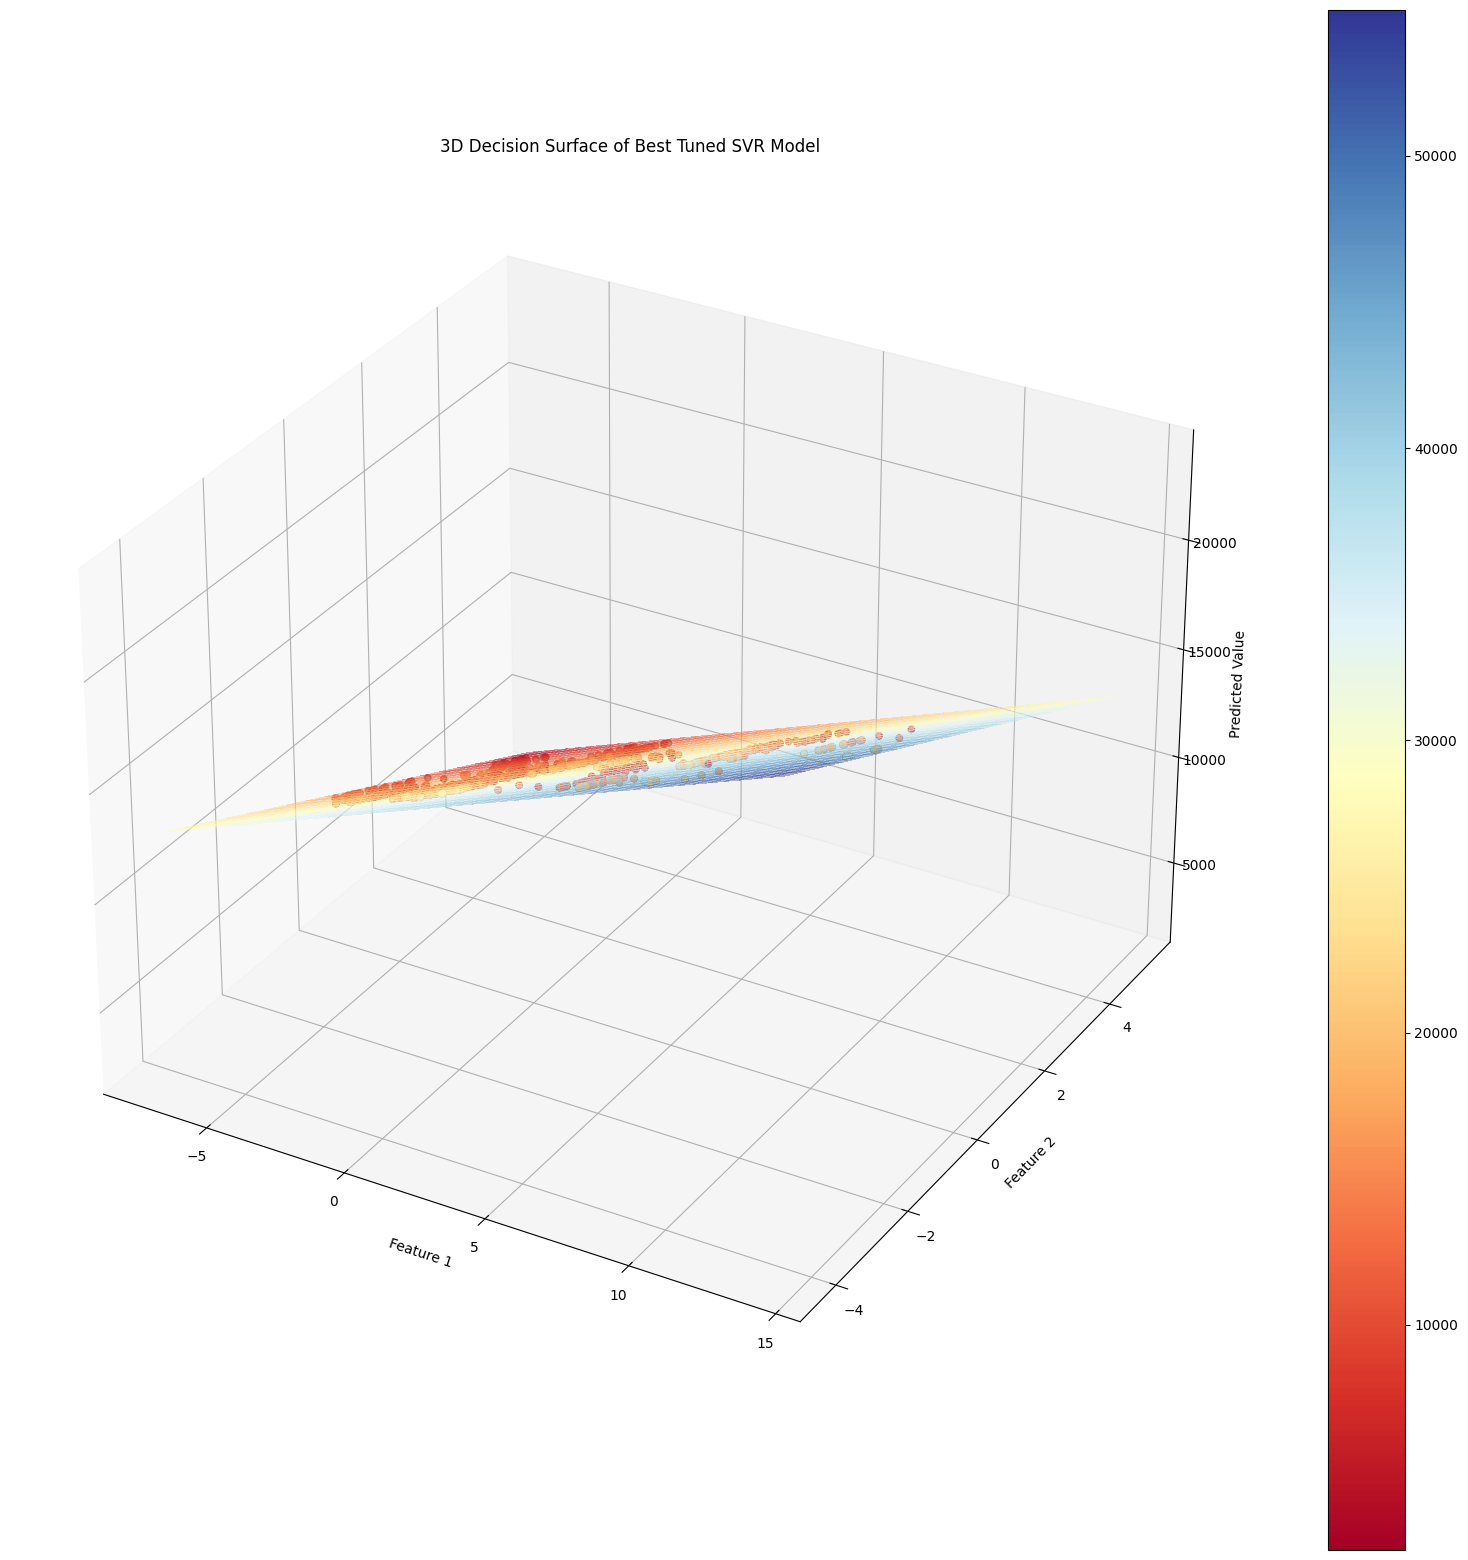

In [ ]:
x_min, x_max = x_test[:, 0].min() - 1, x_test[:, 0].max() + 1
y_min, y_max = x_test[:, 1].min() - 1, x_test[:, 1].max() + 1
step_size = 0.5 
xx, yy = np.meshgrid(np.arange(x_min, x_max, step_size), np.arange(y_min, y_max, step_size))

grid_points = np.stack([xx.ravel(), yy.ravel()], axis=1)
Z = best_model.predict(grid_points)
Z = Z.reshape(xx.shape)

fig = plt.figure(figsize=(20, 20))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.4, linewidth=0, antialiased=False)

Z_test = best_model.predict(x_test)
ax.scatter(x_test[:, 0], x_test[:, 1], Z_test, c=y_test, cmap=plt.cm.RdYlBu, edgecolors='k')

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Predicted Value')
ax.set_title('3D Decision Surface of Best Tuned SVR Model')

plt.colorbar(ax.scatter(x_test[:, 0], x_test[:, 1], Z_test, c=y_test, cmap=plt.cm.RdYlBu))

plt.show()

**Interpretation of Visualization Results**

The visualization sections attempt to illustrate the SVR model's regression surface and the role of Support Vectors in a 2D feature space.

**Regression Hypersurface (2D and 3D)**

The 2D and 3D plots visualize the mapping from the input features (Feature 1 and Feature 2) to the predicted target value (Z).
- 2D Hypersurface: This plot shows the predicted surface as a gradient backdrop, with the test data points scattered on top. The color transitions of the background represent the shifting predicted values as the input features change. The actual data points are highly dispersed across the prediction zones, visually demonstrating the model's struggle to tightly fit the data, which is consistent with the low $R^2$ score.
- 3D Hypersurface: The three-dimensional plot provides the clearest view of the model's complexity. The smooth, contoured surface represents the continuous prediction output (Z) based on the two input features ($x_1$, $x_2$). The predicted values for the test data points are scattered around this surface, confirming the model identifies a non-linear trend. The vertical distance between the actual data points (scattered points) and the predicted surface (smooth mesh) represents the error. The significant vertical spread of the scattered points above and below the surface confirms that a large variance remains unexplained by the current model.

# Conclusion

This project successfully constructs a canonical, scikit-learn-aligned framework for applying and evaluating Support Vector Regression. The systematic comparison of $\text{SVR}$ variants, the exploration of kernel effects, and the use of robust hyperparameter optimization underscore the importance of the $\text{SVR}$ family of models for complex non-linear regression tasks. The visualizations confirm the mechanism of the $\epsilon$-insensitive tube and the sparsity achieved through the selection of support vectors. Ultimately, the project serves as a comprehensive and reproducible guide for leveraging the power of kernel-based methods in predictive modeling, confirming that proper data scaling and targeted parameter tuning are paramount to achieving optimal generalization performance.

# References

- [Support Vector Machines Scikit-Learn](https://scikit-learn.org/stable/modules/svm.html)
- [SVM Regression Scikit-Learn](https://scikit-learn.org/stable/api/sklearn.svm.html)
- [SVM Scikit-Learn](https://en.wikipedia.org/wiki/Support_vector_machine)
- [Support Vector Regression (SVR) using Linear and Non-Linear Kernels in Scikit Learn Geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/support-vector-regression-svr-using-linear-and-non-linear-kernels-in-scikit-learn/)
- [Support Vector Machine (SVM) Algorithm Geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/support-vector-machine-algorithm/)
- [From Theory to Practice: Implementing Support Vector Regression for Predictions in Python](https://medium.com/@niousha.rf/support-vector-regressor-theory-and-coding-exercise-in-python-ca6a7dfda927)